<a href="https://colab.research.google.com/github/mohamed-elaouan/AWH-UM6P-/blob/main/Forecasting_Modeling_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import plotly.graph_objects as go
# from google.colab import files

# fig = go.Figure(data=go.Scatter(x=[1,2,3], y=[4,5,6]))
# fig.write_image("plot.png")
# files.download("plot.png")

### Dependencies

In [2]:
# Install plotly
%%capture
!pip install plotly==5.13.1 kaleido==0.2.1 --force-reinstall

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

> After you saving the `figures` or any thing ( it should be hasn't the `grid` , and when you save it (`dpi` has to be 600 ) , and just description of the figure not else .  

In [4]:
import matplotlib as mpl

mpl.rcParams.update({
    "figure.dpi": 100, #controls figures of notebook
    "savefig.dpi": 600, #print quality

    #background transparent
    "figure.facecolor": "none", #removre white background
    "axes.facecolor": "none",
    "savefig.facecolor": "none", #saved images are transparent

    #font sizes
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,

    "lines.linewidth": 2,
    "axes.linewidth": 1.0,
    "axes.grid": False
})

# Load the Dataset

## Drive Access

In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### Explain the Parameters of the dataset

☀️ Solar Radiation

1. CLRSKY_SFC_SW_DWN — Clear-sky downward shortwave irradiance (ideal sunlight).

2. ALLSKY_SFC_SW_DNI — Direct normal irradiance under real sky conditions.

3. `ALLSKY_SFC_SW_DWN` — Total downward irradiance (direct + diffuse).

4. ALLSKY_SFC_SW_DIFF — Diffuse irradiance scattered by clouds.

5. ALLSKY_KT — Clearness index (ratio of real sky to clear sky).

6. SZA — Solar zenith angle (sun position).

🌡️ Temperature & Humidity

7. T2MWET — Wet bulb temperature (temperature + evaporation).

8. `T2MDEW` — Dew point temperature (condensation threshold).

9. T2M — Air temperature at 2 m.

10. RH2M — Relative humidity (%).

11. `QV2M` — Specific humidity (absolute humidity, g/kg).

🌧️ Precipitation

12. PRECTOTCORR — Corrected precipitation rate (mm/hour).

🌬️ Wind

13. WS50M — Wind speed at 50 m.

14. WD10M — Wind direction at 10 m.

15. `WS10M` — Wind speed at 10 m.

🛤️ Atmospheric Pressure

16. PS — Surface pressure (kPa).

| Parameter              | English Meaning                                                   | Explication en Français                                                                 |
|------------------------|-------------------------------------------------------------------|-------------------------------------------------------------------------------------------|
| CLRSKY_SFC_SW_DWN      | Clear-sky shortwave downward irradiance                           | Rayonnement solaire reçu au sol **sans nuages**, valeur maximale théorique.              |
| ALLSKY_SFC_SW_DNI      | Direct normal irradiance (all sky)                                | Lumière solaire **directe** reçue face au soleil en conditions réelles.                  |
| ALLSKY_SFC_SW_DWN      | Total shortwave downward irradiance (all sky)                     | Rayonnement solaire total (direct + diffus) **avec nuages**.                             |
| ALLSKY_SFC_SW_DIFF     | Diffuse irradiance (all sky)                                      | Lumière solaire **diffusée par les nuages**, arrivée depuis toutes directions.           |
| ALLSKY_KT              | Clearness index                                                   | Indice de clarté du ciel (1 = ciel clair, 0 = très nuageux).                             |
| SZA                    | Solar zenith angle                                                | Angle entre le soleil et la verticale (faible = midi, fort = lever/coucher).            |
| T2MWET                 | Wet bulb temperature                                              | Température prenant en compte **l'évaporation** (humidité réelle).                      |
| T2MDEW                 | Dew point temperature                                             | Température où l’air devient saturé → **début de condensation**.                         |
| T2M                    | Air temperature at 2 m                                            | Température de l’air classique à 2 m du sol.                                             |
| PRECTOTCORR            | Corrected precipitation                                           | Quantité de pluie corrigée (mm/h).                                                       |
| RH2M                   | Relative humidity                                                 | Pourcentage d’humidité par rapport au maximum possible.                                  |
| QV2M                   | Specific humidity                                                 | Quantité réelle de vapeur d’eau (g/kg) — **humidité absolue**.                           |
| WS50M                  | Wind speed at 50 m                                                | Vitesse du vent en hauteur (plus stable que 10 m).                                        |
| WD10M                  | Wind direction at 10 m                                            | Direction du vent (en degrés).                                                           |
| WS10M                  | Wind speed at 10 m                                                | Vitesse du vent proche du sol.                                                           |
| PS                     | Surface pressure                                                   | Pression atmosphérique au sol (kPa).                                                     |


> **Water** Forecasting labels : `QV2M` , `T2MDEW`

> **Energy** Forecasting labels : `WS10M` , `ALLSKY_SFC_SW_DWN`

In [6]:
!wget https://raw.githubusercontent.com/mohamed-elaouan/AWH-UM6P-/refs/heads/main/%5BELJADIDA%2033.25%2C-8.43%20%5D.csv #=>* this is for downloading the dataset if needed

--2026-02-20 09:28:54--  https://raw.githubusercontent.com/mohamed-elaouan/AWH-UM6P-/refs/heads/main/%5BELJADIDA%2033.25%2C-8.43%20%5D.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16861126 (16M) [text/plain]
Saving to: ‘[ELJADIDA 33.25,-8.43 ].csv’

[ELJADIDA 33.25,-8. 100%[===================>]  16.08M  --.-KB/s    in 0.1s    

2026-02-20 09:28:54 (159 MB/s) - ‘[ELJADIDA 33.25,-8.43 ].csv’ saved [16861126/16861126]



In [7]:
import pandas as pd

In [8]:
df=pd.read_csv("[ELJADIDA 33.25,-8.43 ].csv",
               parse_dates=True ,
               index_col="Unnamed: 0"
               )
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 139512 entries, 2010-01-01 00:00:00 to 2025-11-30 23:00:00
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   YEAR                139512 non-null  int64  
 1   MO                  139512 non-null  int64  
 2   DY                  139512 non-null  int64  
 3   HR                  139512 non-null  int64  
 4   CLRSKY_SFC_SW_DWN   139512 non-null  float64
 5   ALLSKY_SFC_SW_DNI   139512 non-null  float64
 6   ALLSKY_SFC_SW_DWN   139512 non-null  float64
 7   ALLSKY_SFC_SW_DIFF  139512 non-null  float64
 8   ALLSKY_KT           139512 non-null  float64
 9   SZA                 139512 non-null  float64
 10  T2MWET              139512 non-null  float64
 11  T2MDEW              139512 non-null  float64
 12  T2M                 139512 non-null  float64
 13  PRECTOTCORR         139512 non-null  float64
 14  RH2M                139512 non-null  float64
 15  

In [9]:
df.index.name = 'datetime'

In [10]:
hourly_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')

In [11]:
df = df.reindex(hourly_index)

In [12]:
df.index.min()

Timestamp('2010-01-01 00:00:00')

In [13]:
df.columns

Index(['YEAR', 'MO', 'DY', 'HR', 'CLRSKY_SFC_SW_DWN', 'ALLSKY_SFC_SW_DNI',
       'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_SW_DIFF', 'ALLSKY_KT', 'SZA', 'T2MWET',
       'T2MDEW', 'T2M', 'PRECTOTCORR', 'RH2M', 'QV2M', 'WS50M', 'WD10M',
       'WS10M', 'PS'],
      dtype='object')

# Feature Enginnering & Selection
1. Prepare the procuss for normalisation the data (by type to column )
2. define a function to process the **Window_size** and **Horizon**

> the description of the Dataset Spliting methodelogie :

+ X=df_modeling[[# the Features & Caractéristique
               'CLRSKY_SFC_SW_DWN',
               'ALLSKY_SFC_SW_DWN',
               'ALLSKY_SFC_SW_DIFF',
               'ALLSKY_KT',
               'T2MWET',
               'T2M',
               'RH2M',
               'WS50M',
               'PS',
              #  Represent a historical data
               'QV2M',
               'T2MDEW',
               "ALLSKY_SFC_SW_DNI",
               "WS10M"]]

+ y=df_modeling[['QV2M',
               'T2MDEW',
               "ALLSKY_SFC_SW_DNI",
               "WS10M" # the target
               ]]





> depend on Model how working on


In [14]:
WINDOW_SIZE = 365
HORIZON  = 365
BATCH_SIZE = 32 # 32

In [15]:
df_modeling=df[[
                # Caractéristiques
                'ALLSKY_SFC_SW_DIFF',
                'ALLSKY_KT',
                'T2MWET',
                'T2M',
                'RH2M',
                'WS50M',
                'PS',
                "ALLSKY_SFC_SW_DNI",
                'CLRSKY_SFC_SW_DWN',
                # Targeted / Horizons
                'ALLSKY_SFC_SW_DWN',
                'QV2M',
                'T2MDEW',
                "WS10M"
                ]]

## Outlier Clean-value from the values

In [16]:
df_modeling.describe().loc["min"] == -999.0

,min
ALLSKY_SFC_SW_DIFF,True
ALLSKY_KT,True
T2MWET,False
T2M,False
RH2M,False
WS50M,False
PS,False
ALLSKY_SFC_SW_DNI,True
CLRSKY_SFC_SW_DWN,True
ALLSKY_SFC_SW_DWN,True


In [17]:
import numpy as np

df_modeling.replace(-999.0, np.nan, inplace=True)

/tmp/ipython-input-600134781.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modeling.replace(-999.0, np.nan, inplace=True)


In [18]:
df_modeling.isna().sum()

,0
ALLSKY_SFC_SW_DIFF,1488
ALLSKY_KT,67216
T2MWET,0
T2M,0
RH2M,0
WS50M,0
PS,0
ALLSKY_SFC_SW_DNI,1488
CLRSKY_SFC_SW_DWN,1488
ALLSKY_SFC_SW_DWN,1488


In [19]:
missing_ratio = df_modeling.isna().mean() * 100
missing_ratio.sort_values(ascending=False)


,0
ALLSKY_KT,48.179368
ALLSKY_SFC_SW_DIFF,1.066575
ALLSKY_SFC_SW_DWN,1.066575
ALLSKY_SFC_SW_DNI,1.066575
CLRSKY_SFC_SW_DWN,1.066575
RH2M,0.000000
T2M,0.000000
T2MWET,0.000000
PS,0.000000
WS50M,0.000000


> we've the `ALLSKY_KT` Variable has 48% precentage of outlier => so we delete it

In [20]:
df_modeling.drop("ALLSKY_KT",axis=1,inplace=True)

/tmp/ipython-input-3209069461.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modeling.drop("ALLSKY_KT",axis=1,inplace=True)


In [21]:
df_modeling.isna().sum()

,0
ALLSKY_SFC_SW_DIFF,1488
T2MWET,0
T2M,0
RH2M,0
WS50M,0
PS,0
ALLSKY_SFC_SW_DNI,1488
CLRSKY_SFC_SW_DWN,1488
ALLSKY_SFC_SW_DWN,1488
QV2M,0


> Replace the `Null` values on 0

In [22]:
solar_cols = [
    "ALLSKY_SFC_SW_DWN",
    "ALLSKY_SFC_SW_DIFF",
    "ALLSKY_SFC_SW_DNI",
    "CLRSKY_SFC_SW_DWN"
]

df_modeling[solar_cols] = df_modeling[solar_cols].fillna(0)

/tmp/ipython-input-2211592002.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modeling[solar_cols] = df_modeling[solar_cols].fillna(0)


In [23]:
df_modeling.isna().sum()

,0
ALLSKY_SFC_SW_DIFF,0
T2MWET,0
T2M,0
RH2M,0
WS50M,0
PS,0
ALLSKY_SFC_SW_DNI,0
CLRSKY_SFC_SW_DWN,0
ALLSKY_SFC_SW_DWN,0
QV2M,0


In [24]:
df_modeling.describe()

,ALLSKY_SFC_SW_DIFF,T2MWET,T2M,RH2M,WS50M,PS,ALLSKY_SFC_SW_DNI,CLRSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DWN,QV2M,T2MDEW,WS10M
count,139512.000000,139512.000000,139512.000000,139512.000000,139512.000000,139512.000000,139512.000000,139512.000000,139512.000000,139512.000000,139512.000000,139512.000000
mean,80.504395,16.884847,19.037556,77.455857,5.322741,101.080710,211.436685,247.862577,212.948893,10.697949,14.732163,4.411400
std,107.523003,3.600641,3.944038,12.461350,2.423665,0.502476,293.047362,323.742899,291.862861,2.556709,3.787124,2.016709
min,0.000000,4.350000,7.070000,16.560000,0.020000,97.880000,0.000000,0.000000,0.000000,4.160000,1.090000,0.010000
25%,0.000000,14.020000,15.890000,68.360000,3.650000,100.770000,0.000000,0.000000,0.000000,8.660000,11.950000,3.000000
50%,8.750000,16.920000,19.030000,78.610000,5.170000,101.020000,0.780000,8.230000,6.620000,10.530000,14.880000,4.240000
75%,144.750000,19.920000,21.850000,87.260000,6.730000,101.360000,431.135000,518.920000,412.880000,12.700000,17.800000,5.600000
max,567.570000,26.350000,34.570000,100.000000,25.170000,103.000000,1198.240000,1043.200000,1035.550000,19.300000,24.590000,20.520000


<Axes: ylabel='ALLSKY_SFC_SW_DWN'>

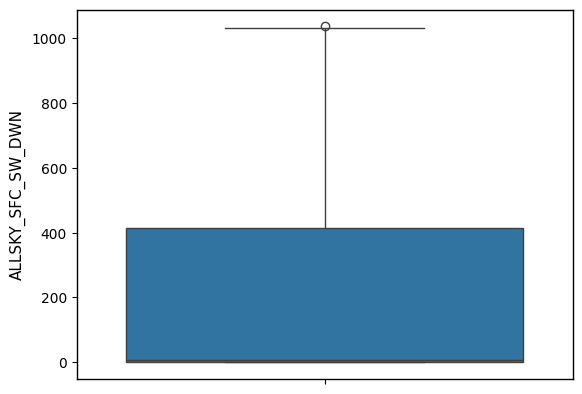

In [25]:
import seaborn as sns
sns.boxplot(df_modeling.ALLSKY_SFC_SW_DWN)

In [26]:
df_modeling.columns

Index(['ALLSKY_SFC_SW_DIFF', 'T2MWET', 'T2M', 'RH2M', 'WS50M', 'PS',
       'ALLSKY_SFC_SW_DNI', 'CLRSKY_SFC_SW_DWN', 'ALLSKY_SFC_SW_DWN', 'QV2M',
       'T2MDEW', 'WS10M'],
      dtype='object')

In [27]:
# df_monthly=df_modeling.resample('ME').mean()
agg_dict_month = {
    'ALLSKY_SFC_SW_DIFF': 'max',
    'ALLSKY_SFC_SW_DNI': 'max',
    'ALLSKY_SFC_SW_DWN': 'max',# target
    'CLRSKY_SFC_SW_DWN': 'max',

    'T2M': 'max',
    'T2MWET': 'max',
    'T2MDEW': 'max',#target

    'WS10M': 'mean',# target
    'WS50M': 'mean',

    'RH2M': 'mean',
    'PS': 'mean',
    'QV2M': 'mean'# target
}

df_monthly = df_modeling.resample("MS").agg(agg_dict_month)

## 1. Data preprosessing

+ `Normalisation`/`Standard (z-score)` the data to granted best **memorie management** and **the best model training performance**

In [216]:
df_modeling.resample("D").mean()

,ALLSKY_SFC_SW_DIFF,T2MWET,T2M,RH2M,WS50M,PS,ALLSKY_SFC_SW_DNI,CLRSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DWN,QV2M,T2MDEW,WS10M
2010-01-01,42.045000,13.280000,15.873333,71.583750,4.254583,101.308750,174.790833,143.590000,105.644583,7.926250,10.685417,3.381250
2010-01-02,28.234583,12.841250,15.419583,72.798333,3.266667,101.180833,283.926667,146.526250,143.195000,7.779167,10.260833,2.636250
2010-01-03,76.050417,14.715417,16.437500,80.889167,6.072500,101.100000,64.301667,139.277083,103.742500,9.307083,12.990833,4.800833
2010-01-04,47.851667,15.133333,16.817083,81.045000,14.008333,100.536250,161.133333,141.455833,112.907917,9.649167,13.451667,11.388750
2010-01-05,44.975417,14.203750,16.125000,77.975417,11.116667,100.549583,163.338750,141.223750,106.000000,8.887917,12.282083,8.929583
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-26,0.000000,13.562500,16.833333,65.279167,7.908333,101.310000,0.000000,0.000000,0.000000,7.692917,10.292917,6.421250
2025-11-27,0.000000,14.917917,17.695833,70.192500,7.532083,101.148750,0.000000,0.000000,0.000000,8.737917,12.142083,5.937917
2025-11-28,0.000000,14.517500,16.729167,75.612500,5.377917,101.267917,0.000000,0.000000,0.000000,8.823333,12.305833,4.436667
2025-11-29,0.000000,14.251250,16.446667,75.282500,3.134583,101.245833,0.000000,0.000000,0.000000,8.670417,12.055000,2.728333


In [28]:
df_monthly

,ALLSKY_SFC_SW_DIFF,ALLSKY_SFC_SW_DNI,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,T2M,T2MWET,T2MDEW,WS10M,WS50M,RH2M,PS,QV2M
2010-01-01,369.85,964.47,640.80,657.42,21.50,18.23,16.99,5.322621,6.599194,78.513495,101.110282,8.449355
2010-02-01,405.86,1044.70,747.97,790.72,22.91,19.51,16.80,6.519494,8.099628,81.851458,100.439420,9.337723
2010-03-01,470.62,1157.75,902.10,919.22,24.18,18.52,16.37,4.994570,6.170269,76.599422,101.053952,8.868266
2010-04-01,558.43,1035.62,968.97,978.12,28.25,21.42,18.40,5.301958,6.496417,79.621931,100.674889,10.243181
2010-05-01,511.94,1007.75,997.78,1022.78,27.59,21.29,19.05,4.852755,5.782782,75.533226,100.881882,10.127204
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-01,541.09,912.48,990.90,1008.80,29.81,24.82,23.10,4.199637,4.885027,78.681532,100.817849,13.982554
2025-08-01,491.64,939.60,955.00,958.65,33.09,26.35,24.59,4.311452,5.222406,82.199731,100.770981,15.040269
2025-09-01,453.32,972.29,920.30,937.75,31.56,24.51,21.84,4.212458,5.320431,78.800542,101.010903,13.237306
2025-10-01,0.00,0.00,0.00,0.00,26.03,22.00,20.53,3.685659,4.472957,83.434099,101.010739,13.058226


In [29]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import joblib

training_size = 0.8 # 0.8 => 80% for training

# Data_Entry_Saved_path="/content/drive/MyDrive/Colab Notebooks/[WORK] UM6P/[ELJADIDA] AWH - Forecasting Modeling Experimentals/Data_Entry_Train_Test/dataset_with_features.joblib"

# Water
feature_Water_cols = ["T2MWET",
                      "T2M",
                      "RH2M",
                      "PS",
                      # Targets
                      'QV2M', 'T2MDEW'
                      ]

target_Water_cols = ['QV2M', 'T2MDEW']
# Energie
target_Energie_cols=["ALLSKY_SFC_SW_DWN" , 'WS10M']

feature_Energie_cols = ["WS50M" ,
                        "ALLSKY_SFC_SW_DIFF" ,
                        "CLRSKY_SFC_SW_DWN",
                        'ALLSKY_SFC_SW_DNI',
                        # Targets
                        "ALLSKY_SFC_SW_DWN" ,
                        'WS10M'
                        ]
#
# Water
# Monthly
X_Water = df_monthly[feature_Water_cols]
y_Water = df_monthly[target_Water_cols]

# Energie
X_Energie = df_monthly[feature_Energie_cols]
y_Energie = df_monthly[target_Energie_cols]

In [30]:
from sklearn.preprocessing import StandardScaler , RobustScaler

X_Water_standard = ['T2MWET','T2M','RH2M','QV2M', 'T2MDEW']
X_Water_robust   = ['PS']

X_Energie_standard = ['WS50M','WS10M']
X_Energie_robust   = ['ALLSKY_SFC_SW_DIFF',
                      'ALLSKY_SFC_SW_DWN','CLRSKY_SFC_SW_DWN','ALLSKY_SFC_SW_DNI' ]

X_Water_scalers_monthly = {}

# Monthly
for col in X_Water_standard:
    sc = StandardScaler()
    sc.fit(X_Water[[col]])
    X_Water_scalers_monthly[col] = sc

for col in X_Water_robust:
    sc = RobustScaler()
    sc.fit(X_Water[[col]])
    X_Water_scalers_monthly[col] = sc

X_Energie_scalers_monthly = {}
X_Energie_scalers_weekly = {}

# Monthly
for col in X_Energie_standard:
    sc = StandardScaler()
    sc.fit(X_Energie[[col]])
    X_Energie_scalers_monthly[col] = sc

for col in X_Energie_robust:
    sc = RobustScaler()
    sc.fit(X_Energie[[col]])
    X_Energie_scalers_monthly[col] = sc

In [31]:
# Water
y_Water_scalers_monthly = {}
y_Water_scalers_weekly = {}
for col in target_Water_cols:
    sc = StandardScaler()
    sc.fit(y_Water[[col]])
    y_Water_scalers_monthly[col] = sc

#Energie
y_Energie_scalers_monthly = {}
y_Energie_scalers_weekly = {}
for col in target_Energie_cols:
    sc = RobustScaler()
    sc.fit(y_Energie[[col]])
    y_Energie_scalers_monthly[col] = sc


In [32]:
def transform_df(df, scalers):
    df_scaled = df.copy()
    for col, sc in scalers.items():
        df_scaled[col] = sc.transform(df[[col]])
    return df_scaled

def inverse_df(df_scaled, scalers):
    df_back = df_scaled.copy()
    for col, sc in scalers.items():
        df_back[col] = sc.inverse_transform(df_scaled[[col]])
    return df_back


In [33]:
# 6️⃣ Transformation Water
# Monthly_data
X_Water_scaled = transform_df(X_Water, X_Water_scalers_monthly)
y_Water_scaled = transform_df(y_Water, y_Water_scalers_monthly)

X_Energie_scaled = transform_df(X_Energie, X_Energie_scalers_monthly)
y_Energie_scaled = transform_df(y_Energie, y_Energie_scalers_monthly)


# Inverse Scaling
# X_train_orignal = inverse_df(X_train_scaled, X_scalers)
# X_test_orignal  = inverse_df(X_test_scaled, X_scalers)

# y_train_orignal = inverse_df(y_train_scaled, y_scalers)
# y_test_orignal  = inverse_df(y_test_scaled, y_scalers)

> reverse scalling

for prediction results

In [34]:
def y_inverse_scaling(y_pred,y_scalers,target_cols):
    # y_pred=y_test
    # 1. Get the shape
    n_samples, n_horizon, n_targets = y_pred.shape # e.g., (26000, 24, 4)
    # 2. Reshape to 2D for sklearn (Stitch all windows together)
    y_reshaped = y_pred.reshape(-1, n_targets)
    # Cast into DataFrame
    y_reshaped = pd.DataFrame(y_reshaped,columns=target_cols)
    # reinverse scalling
    y_reshaped = inverse_df(y_reshaped,y_scalers)

    # Reshape/returned on the original state
    y_pred_original = y_reshaped.to_numpy().reshape(n_samples, n_horizon, n_targets)
    return y_pred_original

# Automating & Global Variables

## [Planning] & Helper_Function

### making prediction function

In [35]:
import tensorflow as tf
def make_preds(model,input_data):
  """
  Uses model to make predictions input_data
  """
  forecast=model.predict(input_data)
  return tf.squeeze(forecast)# 1D

> my info about my dataset :

| Terme         | Signification                              |
| ------------- | ------------------------------------------ |
| Multivariate  | Plusieurs variables d’entrée (13 colonnes) |
| Multi-output  | Plusieurs cibles (4 variables)             |
| Multi-horizon | Plusieurs pas futurs (ex: 24h ahead)       |


### Algorithms recommended for **Experiement_Modeling**



| Modèle        | Best Window | Best Horizon | Usage                     |
| ------------- | ----------- | ------------ | ------------------------- |
| LSTM          | **168**     | **24**       | Perf générale             |
| GRU           | **168**     | **24**       | Plus rapide LSTM          |
| CNN-LSTM      | **168–336** | **24**       | Local + séquence          |
| Transformer   | **336**     | **24**       | Long patterns             |
| TFT           | **336–720** | **24**       | Meilleur contexte exogène |


| Modèle                                | Multivariate | Multi-Output | Multi-Horizon | Statut | Commentaire                |
| ------------------------------------- | ------------ | ------------ | ------------- | ------ | -------------------------- |
| **LSTM (seq2seq)**                    | ✅            | ✅            | ✅             | 🟢     | Très utilisé en énergie    |
| **GRU (seq2seq)**                     | ✅            | ✅            | ✅             | 🟢     | Plus léger que LSTM        |
| **CNN-LSTM**                          | ✅            | ✅            | ✅             | 🟢     | Bon pour patterns locaux   |
| **Temporal Fusion Transformer (TFT)** | ✅            | ✅            | ✅             | 🟢     | ⭐ SOTA industrie           |
| **Transformer (Time Series)**         | ✅            | ✅            | ✅             | 🟢     | Longues dépendances        |
| **N-BEATSx**                          | ✅            | ✅            | ✅             | 🟢     | Spécialisé forecasting     |
| **DeepAR (multivariate)**             | ✅            | 🟡           | ✅             | 🟡     | Multi-output indirect      |
| **XGBoost (multi-output)**            | ✅            | 🟡           | 🟡            | 🟡     | Feature engineering requis |
| **Random Forest (multi-output)**      | ✅            | 🟡           | 🟡            | 🟡     | Baseline seulement         |
| **SARIMAX**                           | 🟡           | 🔴           | 🟡            | 🔴     | Très limité                |
| **Prophet**                           | 🟡           | 🔴           | 🟡            | 🔴     | Univarié par design        |


> So, based on **my simples research**; these the algotithems who it seems correpond on my problematique `Deep Learning Solution`:
* RNNs Architectures (LSTM , GRU ,etc ....) => `W: 168 , H: 24`
* CNNs/RNNs Archi => `W: 168 , H: 24`
* Advanced Models : (available on [**Darts**](https://unit8co.github.io/darts/generated_api/darts.models.forecasting.html)-Amazon ) => `W: 168,336,720 , H: 24`
  * Temporal Fusion Transformer (**TFT**) ⭐
  * Temporal Convolutional Network (**TCN**)
* Transformers : => `W: 168,336 , H: 24`
  * Informer - Autoformer - PatchTST
  
> **Ressources :** Advances Forecasting models is available on  **Darts-platform(website)**(by Amazon)




### Metrics-Models Experimental performamnces


| **Métrique**     | **Type**           | **Dépendance à l’échelle** | **Robustesse aux outliers** | **Adaptée multi-horizon** | **Cas d’usage principal**       |
| ---------------- | ------------------ | -------------------------- | --------------------------- | ------------------------- | ------------------------------- |
| **MAE**          | Erreur absolue     | Oui                        | ✅ Bonne                     | ✅ Oui                     | ⭐ Métrique principale (énergie) |
| **RMSE**         | Erreur quadratique | Oui                        | ❌ Faible                    | ✅ Oui                     | Pénaliser les pics              |
| **sMAPE**        | % symétrique       | Non                        | ⚠️ Moyenne                  | ✅ Oui                     | Comparaison entre variables     |
| **WAPE**         | % pondéré          | Non                        | ✅ Bonne                     | ✅ Oui                     | Load & énergie agrégée          |
| **MASE**         | Erreur normalisée  | Non                        | ✅ Bonne                     | ✅ Oui                     | Comparaison au naïf             |
| **Pinball Loss** | Quantile           | Oui                        | ✅ Bonne                     | ✅ Oui                     | Prévision probabiliste          |
| **R²**           | Variance expliquée | Non                        | ❌ Faible                    | ⚠️ Limité                 | Analyse complémentaire          |
| **MAPE**         | %                  | Non                        | ❌ Très faible               | ⚠️ Risqué                 | ❌ À éviter (zéro)               |


| **Modèle**                        | **Window size recommandé** | **Horizon** | **Métriques recommandées** |
| --------------------------------- | -------------------------- | ----------- | -------------------------- |
| Temporal Fusion Transformer (TFT) | 336 – 720                  | 24          | MAE, RMSE, MASE, Pinball   |
| LSTM Seq2Seq                      | 168 – 336                  | 24          | MAE, RMSE, sMAPE           |
| GRU Seq2Seq                       | 168 – 336                  | 24          | MAE, RMSE, sMAPE           |
| Transformer (Time-Series)         | 336                        | 24          | MAE, RMSE, MASE            |
| N-BEATSx                          | 336                        | 24          | MAE, RMSE, MASE            |
| CNN-LSTM                          | 168 – 336                  | 24          | MAE, RMSE                  |

> based on this Study i'll implement a function for `Evaluation_models` => MAE , RMSE , MASE , MAPE


In [36]:
df_modeling.columns[-4:]

Index(['ALLSKY_SFC_SW_DWN', 'QV2M', 'T2MDEW', 'WS10M'], dtype='object')

### Evaluation Function

In [37]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def extract_1d_series(y_train, target_index):
    return y_train[:, -1, target_index]

def evaluate_multitarget_multihorizon(
    y_true,
    y_pred,
    y_train,
    target_names,
    seasonality=24,
    eps=1e-8
):
    """
    y_true, y_pred: (n_samples, H, N_targets)
    y_train: (n_train_samples, window, N_targets)
    """

    H = y_true.shape[1]
    horizon_names = [f"t+{i+1}" for i in range(H)]

    results = {}

    for t_idx, target in enumerate(target_names):
        results[target] = {}

        # ---- Extract 1D training series for MASE
        train_series_1d = extract_1d_series(y_train, t_idx)

        naive_mae = np.mean(
            np.abs(
                train_series_1d[seasonality:]
                - train_series_1d[:-seasonality]
            )
        )

        for h in range(H):
            yt = y_true[:, h, t_idx]
            yp = y_pred[:, h, t_idx]

            mae = mean_absolute_error(yt, yp)
            rmse = np.sqrt(mean_squared_error(yt, yp))
            mape = np.mean(np.abs((yt - yp) / (yt + eps))) * 100
            r2 = r2_score(yt, yp)
            mase = mae / (naive_mae + eps)

            results[target][horizon_names[h]] = {
                "MAE": mae,
                "RMSE": rmse,
                "MAPE (%)": mape,
                "R2": r2,
                "MASE": mase
            }

        # ---- Average over horizons
        results[target]["Average"] = {
            "MAE": np.mean([results[target][h]["MAE"] for h in horizon_names]),
            "RMSE": np.mean([results[target][h]["RMSE"] for h in horizon_names]),
            "MAPE (%)": np.mean([results[target][h]["MAPE (%)"] for h in horizon_names]),
            "R2": np.mean([results[target][h]["R2"] for h in horizon_names]),
            "MASE": np.mean([results[target][h]["MASE"] for h in horizon_names])
        }
        final_summary = {}

        for var, metrics in results.items():
            # filtrer les horizons t+... et ignorer 'Average'
            horizons = [v for k, v in metrics.items() if k != 'Average']

            # initialiser dictionnaire pour stocker les moyennes
            mean_metrics = {}

            # parcourir les clés de métriques
            for metric_name in horizons[0].keys():
                # réduire avec np.mean
                mean_metrics[metric_name] = float(np.mean([h[metric_name] for h in horizons]))

            final_summary[var] = mean_metrics

    return final_summary

### Full evaluation model Function

In [38]:
def make_full_evaluation_model(model, X_test, y_test, y_train,target_names,with_originals_value=False):
    """
    Makes predictions with the model and evaluates them.
    """
    print("Evaluation results:", model.evaluate(X_test, y_test))

    # # * metrics calculation
    target_names = target_names#['QV2M', 'T2MDEW', 'ALLSKY_SFC_SW_DNI', 'WS10M']

    model_preds = model.predict(X_test)
    # Cast it into dataframe first f
    # Reverse scalling
    if with_originals_value == True:

      model_preds_originals= y_inverse_scaling(model_preds)
      y_test_orignals=y_inverse_scaling(y_test)
      y_train_orignals=y_inverse_scaling(y_train)

      metrics = evaluate_multitarget_multihorizon(
                                                  y_true=y_test_orignals,          # (n_samples, 4, 4)
                                                  y_pred=model_preds_originals,          # (n_samples, 4, 4)
                                                  y_train=y_train_orignals,        # (111418, 24, 4)
                                                  target_names=target_names,
                                                  seasonality=24          # hourly data # Fixed hyperparameter
                                              )
    else :
      metrics = evaluate_multitarget_multihorizon(
                                                  y_true=y_test,          # (n_samples, 4, 4)
                                                  y_pred=model_preds,          # (n_samples, 4, 4)
                                                  y_train=y_train,        # (111418, 24, 4)
                                                  target_names=target_names,
                                                  seasonality=24          # hourly data # Fixed hyperparameter
                                              )
    # return [ f"[{metric}] for {key}: {metrics[key][metric]}" for key in metrics.keys() for metric in metrics[key]]
    return [ f"MAE for {key}: {metrics[key]['MAE']}" for key in metrics.keys()],"--"*20, [ f"RMSE for {key}: {metrics[key]['RMSE']}" for key in metrics.keys()],"--"*20, [ f"MAPE (%) for {key}: {metrics[key]['MAPE (%)']}" for key in metrics.keys()],"--"*20, [ f"R2 for {key}: {metrics[key]['R2']}" for key in metrics.keys()],"--"*20, [ f"MASE for {key}: {metrics[key]['MASE']}" for key in metrics.keys()]

### Model_check_point Configuration

In [39]:
import os

colab_saved_models="/content/drive/MyDrive/Colab Notebooks/[WORK] UM6P/[ELJADIDA] AWH - Forecasting Modeling Experimentals/model_experiments"

def create_model_checkpoint(model_name, saved_path=colab_saved_models):
    # Create the folder if necessary
    os.makedirs(saved_path, exist_ok=True)

    # Create the full file path ending with .keras
    file_path = os.path.join(saved_path, f"{model_name}.keras")

    return tf.keras.callbacks.ModelCheckpoint(
        filepath=file_path,  # Just use the file_path directly
        verbose=0,
        monitor="val_loss",
        save_best_only=True
    )

### Dataset perform Pipeline

In [40]:
# %%capture
# !pip install tensorflow

In [41]:
# import tensorflow as tf

# def prepare_pipeline(X_train , X_test , y_train , y_test , batch_size=BATCH_SIZE):
#     # *Transforme into perform data in "tf.data"
#     tf_X_train = tf.data.Dataset.from_tensor_slices(X_train)
#     tf_y_train = tf.data.Dataset.from_tensor_slices(y_train)

#     tf_X_test = tf.data.Dataset.from_tensor_slices(X_test)
#     tf_y_test = tf.data.Dataset.from_tensor_slices(y_test)
#     # Combine features and labels
#     train_dataset = tf.data.Dataset.zip((tf_X_train,tf_y_train))
#     test_dataset = tf.data.Dataset.zip((tf_X_test,tf_y_test))
#     #
#     train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
#     test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#     return train_dataset , test_dataset

### plot_loss_curve

In [42]:
import matplotlib.pyplot as plt
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  epochs = range(len(history.history['loss']))
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()
  plt.show()

### Load_[model]_from_drive

In [43]:
def load_model_from_drive(model_name):
  path=colab_saved_models+f"/{model_name}.keras"
  model=tf.keras.models.load_model(path)
  return model

### Load tha [data_Entry] from the **Drive**

In [44]:
# def load_data_entry(path=Data_Entry_Saved_path):
#   bundle = joblib.load(path)

#   X_train=bundle['X_train']
#   X_test=bundle['X_test']
#   y_train=bundle['y_train']
#   y_test=bundle['y_test']
#   feature_preprocessor = bundle["feature_preprocessor"],
#   target_preprocessor = bundle["target_preprocessor"],
#   train_dataset_pipeline = bundle["train_dataset"],
#   test_dataset_pipeline = bundle["test_dataset"]

#   return X_train , X_test , y_train , y_test , train_dataset_pipeline , test_dataset_pipeline , feature_preprocessor, target_preprocessor

| Batch | LR     |
| ----- | ------ |
| 128   | 6e-4   |
| 64    | 3e-4   |
| 32    | 1.5e-4 |


# Metrics for Obtain the Best Performance for **AWH**

the best evaluation metrics presented as clear points for your AWH long-horizon (5-year, monthly) forecasting experiment:

>  Core Metrics (For Energy & Water Models)

+ MAE (Mean Absolute Error) → Primary metric (robust, interpretable in physical units)

+ RMSE (Root Mean Squared Error) → Detects large prediction errors

+ MASE (Mean Absolute Scaled Error) → Scale-independent comparison across models

+ R² (Coefficient of Determination) → Measures explained variance

# Water Parameters Forecasting

## Water Data Prep For Keras models

In [45]:
WINDOW_SIZE,HORIZON

(48, 60)

In [46]:
target_indices = [feature_Water_cols.index(var) for var in target_Water_cols]
data = X_Water_scaled.values

In [47]:
target_indices,feature_Water_cols

([4, 5], ['T2MWET', 'T2M', 'RH2M', 'PS', 'QV2M', 'T2MDEW'])

In [48]:
def create_sequences(data, input_steps, output_steps, target_indices):
    X, y = [], []
    for i in range(len(data) - input_steps - output_steps):
        X.append(data[i : i + input_steps])

        # y shape → (output_steps, n_targets)
        future = data[i + input_steps : i + input_steps + output_steps, target_indices]
        y.append(future)

    return np.array(X), np.array(y)

In [49]:
input_steps = WINDOW_SIZE # 48 month
output_steps = HORIZON # 60 month

#sliding-window
X, y = create_sequences(data, input_steps, output_steps, target_indices) #X -> past 60 days of all features and y -> next 30 days of QV2M only

# y_flat = y.reshape(y.shape[0], -1)

#Split data into Train/Test splits
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:] # :split=first 80% for training and split:=last 20% for test
y_train, y_test = y[:split], y[split:]

In [50]:
X_val=X[-10:,:,:]
y_val=y[-10:,:,:]

In [51]:
X_train.shape, X_test.shape,y_train.shape, y_test.shape , y_val.shape, X_val.shape

((66, 48, 6), (17, 48, 6), (66, 60, 2), (17, 60, 2), (10, 60, 2), (10, 48, 6))

## LSTM

In [52]:
metrics_models_preformans=[]

In [53]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization, Reshape
)

tf.random.set_seed(42)

model = Sequential([
    # ===== LSTM stack =====
    LSTM(
        720,
        return_sequences=True,
        input_shape=(input_steps, len(feature_Water_cols))
    ),
    BatchNormalization(),
    Dropout(0.2),

    LSTM(512, return_sequences=True),
    Dropout(0.2),

    LSTM(256),
    Dropout(0.2),

    # ===== Projection multi-horizon =====
    Dense(128, activation="relu"),
    Dropout(0.2),

    Dense(output_steps * len(target_Water_cols)),
    Reshape((output_steps, len(target_Water_cols)))
],name="LSTM_Model_Water_Monthly")

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mae",#tf.keras.losses.Huber(delta=1.0)
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.MeanSquaredError(name="mse")
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [54]:
# Training
# history = model.fit(
#     X_train,
#     y_train,
#     validation_data=(X_test, y_test),
#     epochs=1000,
#     batch_size=16,   # ⬅️ recommandé
#     verbose=1,
#     callbacks=[
#         create_model_checkpoint(model.name),
#         tf.keras.callbacks.EarlyStopping(
#             monitor="val_loss",
#             patience=15,
#             restore_best_weights=True,
#             min_delta=1e-4,
#             verbose=1
#         ),
#         tf.keras.callbacks.ReduceLROnPlateau(
#             monitor="val_loss",
#             factor=0.5,
#             patience=5,
#             min_lr=1e-5,
#             verbose=1
#         )
#     ]
# )
# plot_loss_curves(history)

In [55]:
model = load_model_from_drive("LSTM_Model_Water_Monthly")

In [56]:
y_pred = model.predict(X_test)

# Inverse transform
y_pred =y_inverse_scaling(y_pred,y_Water_scalers_monthly,target_Water_cols)
y_test_original =y_inverse_scaling(y_test,y_Water_scalers_monthly,target_Water_cols)

n_targets = len(target_Water_cols)

y_pred_scaled = y_pred.reshape(-1, output_steps, n_targets)
y_test_scaled = y_test_original.reshape(-1, output_steps, n_targets)

y_pred_inv = []
y_true_inv = []
metrics = {}

for j, var in enumerate(target_Water_cols):

    idx = feature_Water_cols.index(var)

    # Empty arrays for inverse transform
    temp_pred = np.zeros((y_pred_scaled.shape[0] * output_steps, len(feature_Water_cols)))
    temp_true = np.zeros((y_test_scaled.shape[0] * output_steps, len(feature_Water_cols)))

    # Fill values
    temp_pred[:, idx] = y_pred_scaled[:, :, j].flatten()
    temp_true[:, idx] = y_test_scaled[:, :, j].flatten()

    y_pred_inv.append(temp_pred) #pred_inv
    y_true_inv.append(temp_true) #true_inv

    # Metrics
    rmse = np.sqrt(mean_squared_error(temp_true,temp_pred))#true_inv, pred_inv
    mae = mean_absolute_error(temp_true,temp_pred)
    r2 = r2_score(temp_true,temp_pred)

    metrics[var] ={
        "R2": r2,
        "RMSE": rmse,#exemple: T2MDEW => RMSE: 1.3684 means the prediction is wrong by about 1°C on average => exemple: If the real dew point is 12°C, the model predicts something like 11°C or 13°C
        "MAE": mae
    }

    #print(f"{var} => R2: {r2:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}") #MASE: {mase:.4f}
df_metrics_Water = pd.DataFrame(metrics).T
df_metrics_Water

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step


,R2,RMSE,MAE
QV2M,0.973598,0.339869,0.110800
T2MDEW,0.958337,0.527983,0.161769


In [57]:
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import numpy as np
# import pandas as pd

# y_pred = model.predict(X_test)

# # Inverse transform
# y_pred = y_inverse_scaling(y_pred, y_Water_scalers_monthly, target_Water_cols)
# y_test_original = y_inverse_scaling(y_test, y_Water_scalers_monthly, target_Water_cols)

# n_targets = len(target_Water_cols)

# y_pred_scaled = y_pred.reshape(-1, output_steps, n_targets)
# y_test_scaled = y_test_original.reshape(-1, output_steps, n_targets)

# metrics = {}

for j, var in enumerate(target_Water_cols):

    temp_pred = np.zeros((y_pred_scaled.shape[0] * output_steps, len(feature_Water_cols)))
    temp_true = np.zeros((y_test_scaled.shape[0] * output_steps, len(feature_Water_cols)))

    # Fill values
    temp_pred[:, idx] = y_pred_scaled[:, :, j].flatten()
    temp_true[:, idx] = y_test_scaled[:, :, j].flatten()

    y_pred_inv.append(temp_pred) #pred_inv
    y_true_inv.append(temp_true) #true_inv

    rmse = np.sqrt(mean_squared_error(temp_true,temp_pred))#true_inv, pred_inv
    mae = mean_absolute_error(temp_true,temp_pred)
    r2 = r2_score(temp_true,temp_pred)

    # ===== MASE =====
    # Naive forecast (lag-1)
    naive_errors = np.abs(temp_true[1:] - temp_true[:-1])
    mae_naive = np.mean(naive_errors)

    if mae_naive == 0:
        mase = np.nan
    else:
        mase = mae / mae_naive

    metrics[var] = {
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "MASE": mase
    }

df_metrics_Water = pd.DataFrame(metrics).T
df_metrics_Water

,R2,RMSE,MAE,MASE
QV2M,0.973598,0.339869,0.110800,0.625768
T2MDEW,0.958337,0.527983,0.161769,0.646758


In [58]:
metrics_models_preformans.append({"LSTM": metrics})

In [59]:
metrics_models_preformans

[{'LSTM': {'QV2M': {'R2': 0.973597532714709,
    'RMSE': np.float64(0.33986944992182866),
    'MAE': 0.11080017550028655,
    'MASE': np.float64(0.6257683858766968)},
   'T2MDEW': {'R2': 0.9583374043706933,
    'RMSE': np.float64(0.5279826993164112),
    'MAE': 0.16176882840449489,
    'MASE': np.float64(0.6467579642733902)}}}]

In [60]:
X_train.shape

(66, 48, 6)

In [61]:
y_train_original =y_inverse_scaling(y_train,
                                    y_Water_scalers_monthly,
                                    target_Water_cols
                                   )

### Prediction Plot

> `T2MDEW`

In [62]:
y_train_original[2,-1,:]

array([ 7.86754464, 14.69      ])

In [63]:
# y_pred = np.insert(y_pred,0,y_train_original[2,-1,:])

In [64]:
y_pred.shape

(17, 60, 2)

In [65]:
y_test_original[:,:,1].shape , y_pred[:,:,1].shape

((17, 60), (17, 60))

In [66]:
residuals = y_test_original[:,:,1] - y_pred[:,:,1]
sigma = np.std(residuals, axis=0)  # per horizon

In [67]:
z = 1.96  # 95% confidence

lower_ci = y_pred[:,:,1] - z * sigma
upper_ci = y_pred[:,:,1] + z * sigma

In [68]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# =========================
# 1. CREATE MONTHLY TIME AXIS
# =========================
n_train = 66
n_test = 17
n_total = n_train + n_test
last_month = pd.Timestamp("2025-12-31")
X_time = pd.date_range(end=last_month, periods=n_total, freq="ME")

X_train_time = X_time[:n_train]
X_test_time = X_time[n_train:]

# =========================
# 2. EXTRACT DATA FOR HORIZON h
# =========================
h = 0
train_vals = y_train_original[:, h, 1]
test_vals  = y_test_original[:, h, 1]
pred_vals  = y_pred[:, h, 1]
col_name="T2MDEW"
Error=0.478144
# =========================
# 3. PREPARE CONTINUITY
# =========================
last_train_val = train_vals[-1]
last_train_time = X_train_time[-1]

# Extended arrays for a continuous graph
X_test_extended = pd.DatetimeIndex([last_train_time]).append(X_test_time)
pred_vals_extended = np.concatenate([[last_train_val], pred_vals])

# Error bars usually only apply to actual predictions (not the connection point)
# We create a list for error bars that is 0 at the start (the connection point)
# and the fixed value for the rest.

error_values = [0] + [Error] * len(pred_vals)
# =========================
# 4. FULL PLOT
# =========================
fig = go.Figure()

# --- Train Trace ---
fig.add_trace(go.Scatter(
    x=X_train_time,
    y=train_vals,
    mode='lines',
    name='Train',
    line=dict(color='black', width=2)
))

# --- Prediction Trace (Now Continuous with Training) ---
fig.add_trace(go.Scatter(
    x=X_test_extended,       # Use extended time
    y=pred_vals_extended,    # Use extended values
    mode='lines+markers',
    name='Prediction',
    line=dict(color='red', width=2, dash='dash'),
    marker=dict(size=8, color='red', symbol='circle'),
    error_y=dict(
        type='data',         # Changed to 'data' to allow 0 at the first point
        array=error_values,  # Full interval
        symmetric=True,
        color='blue',
        thickness=1.5,
        width=6
    )
))

# --- Layout ---
fig.update_layout(
    title=f"Continuous Forecast – Horizon {h}",
    xaxis_title="Date",
    yaxis_title=col_name,
    xaxis=dict(
        tickformat="%Y-%m",
        dtick="M12",
        showgrid=True,
        range=[X_time[0] - pd.DateOffset(months=2), X_time[-1] + pd.DateOffset(months=2)]
    ),
    yaxis=dict(showgrid=True),
    template="plotly_white",
    width=1100,
    height=600,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()

In [69]:
df_metrics_Water["RMSE"]["T2MDEW"]

np.float64(0.5279826993164112)

> QV2M

In [70]:
residuals = y_test_original[:,:,0] - y_pred[:,:,0]
sigma = np.std(residuals, axis=0)  # per horizon

In [71]:
z = 1.96  # 95% confidence

lower_ci = y_pred[:,:,0] - z * sigma
upper_ci = y_pred[:,:,0] + z * sigma

In [72]:
import plotly.graph_objects as go
import pandas as pd

# =========================
# 1. CREATE MONTHLY TIME AXIS WITH 83 POINTS ENDING IN 2025
# =========================
n_total = y_train.shape[0] + y_test_original.shape[0]  # 66 + 17 = 83
last_month = pd.Timestamp("2025-12-31")
X_time = pd.date_range(end=last_month, periods=n_total, freq="ME")

n_train = y_train.shape[0]  # 66
n_test = y_test_original.shape[0]  # 17

X_train_time = X_time[:n_train]
X_test_time = X_time[n_train:]

# =========================
# 2. EXTRACT DATA FOR HORIZON h
# =========================
h = 0
train_vals = y_train_original[:, h, 0]      # shape: (66,)
test_vals  = y_test_original[:, h, 0]       # shape: (17,)
pred_vals  = y_pred[:, h, 0]                # shape: (17,)
ci_low     = lower_ci[:, h]                 # shape: (17,)
ci_high    = upper_ci[:, h]                 # shape: (17,)

# =========================
# 3. ADD LAST TRAIN VALUE TO TEST & PRED FOR CONTINUITY
# =========================
# Last train timestamp and value
last_train_time = X_train_time[-1]
last_train_val = train_vals[-1]

# Extended time axis for test (includes last train point)
X_test_extended = pd.DatetimeIndex([last_train_time]).append(X_test_time)

# Extend test and prediction arrays
test_vals_extended = np.concatenate([[last_train_val], test_vals])
pred_vals_extended = np.concatenate([[last_train_val], pred_vals])

# For CI: we usually don't show CI at the衔接 point (it's observed, not predicted)
# So CI stays aligned with original X_test_time (no prepend)

# =========================
# 4. PLOT
# =========================
fig = go.Figure()

# Train (up to last point)
fig.add_trace(go.Scatter(
    x=X_train_time,
    y=train_vals,
    mode='lines',
    name='Train',
    line=dict(color='black', width=2)
))

# Test (starting from last train point)
fig.add_trace(go.Scatter(
    x=X_test_extended,
    y=test_vals_extended,
    mode='lines',
    name='Test',
    line=dict(color='blue', width=2)
))

# Prediction (starting from last train point)
fig.add_trace(go.Scatter(
    x=X_test_extended,
    y=pred_vals_extended,
    mode='lines',
    name='Prediction',
    line=dict(color='red', dash='dash', width=2)
))

# Confidence Interval (only over forecast horizon, not the衔接 point)
fig.add_trace(go.Scatter(
    x=X_test_time.tolist() + X_test_time[::-1].tolist(),
    y=ci_high.tolist() + ci_low[::-1].tolist(),
    fill='toself',
    fillcolor='rgba(173,216,230,0.3)',
    line=dict(color='rgba(255,255,255,0)'),
    showlegend=False,
    name='95% CI'
))

# Layout
fig.update_layout(
    title=f"Monthly Forecast Ending in 2025 – Horizon {h}",
    xaxis_title="Date",
    yaxis_title="QV2M",
    xaxis=dict(
        tickformat="%Y-%m",
        dtick="M12",
        showgrid=True,
        range=[X_time[0] - pd.DateOffset(months=2), X_time[-1] + pd.DateOffset(months=2)]
    ),
    yaxis=dict(showgrid=True),
    template="plotly_white",
    width=1100,
    height=500
)

fig.show()

In [73]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# =========================
# 1. CREATE MONTHLY TIME AXIS
# =========================
n_train = 66
n_test = 17
n_total = n_train + n_test
last_month = pd.Timestamp("2025-12-31")
X_time = pd.date_range(end=last_month, periods=n_total, freq="ME")

X_train_time = X_time[:n_train]
X_test_time = X_time[n_train:]

# =========================
# 2. EXTRACT DATA FOR HORIZON h
# =========================
h = 0
train_vals = y_train_original[:, h, 0]
test_vals  = y_test_original[:, h, 0]
pred_vals  = y_pred[:, h, 0]
col_name="QV2M"
Error=0.323676
# =========================
# 3. PREPARE CONTINUITY
# =========================
last_train_val = train_vals[-1]
last_train_time = X_train_time[-1]

# Extended arrays for a continuous graph
X_test_extended = pd.DatetimeIndex([last_train_time]).append(X_test_time)
pred_vals_extended = np.concatenate([[last_train_val], pred_vals])

# Error bars usually only apply to actual predictions (not the connection point)
# We create a list for error bars that is 0 at the start (the connection point)
# and the fixed value for the rest.

error_values = [0] + [Error] * len(pred_vals)

# =========================
# 4. FULL PLOT
# =========================
fig = go.Figure()

# --- Train Trace ---
fig.add_trace(go.Scatter(
    x=X_train_time,
    y=train_vals,
    mode='lines',
    name='Train',
    line=dict(color='black', width=2)
))

# --- Prediction Trace (Now Continuous with Training) ---
fig.add_trace(go.Scatter(
    x=X_test_extended,       # Use extended time
    y=pred_vals_extended,    # Use extended values
    mode='lines+markers',
    name='Prediction',
    line=dict(color='red', width=2, dash='dash'),
    marker=dict(size=8, color='red', symbol='circle'),
    error_y=dict(
        type='data',         # Changed to 'data' to allow 0 at the first point
        array=error_values,  # Full interval
        symmetric=True,
        color='blue',
        thickness=1.5,
        width=6
    )
))

# --- Layout ---
fig.update_layout(
    title=f"Continuous Forecast – Horizon {h}",
    xaxis_title="Date",
    yaxis_title=col_name,
    xaxis=dict(
        tickformat="%Y-%m",
        dtick="M12",
        showgrid=True,
        range=[X_time[0] - pd.DateOffset(months=2), X_time[-1] + pd.DateOffset(months=2)]
    ),
    yaxis=dict(showgrid=True),
    template="plotly_white",
    width=1100,
    height=600,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()

In [74]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# =========================
# 1. CREATE MONTHLY TIME AXIS
# =========================
n_train = 66
n_test = 17
n_total = n_train + n_test
last_month = pd.Timestamp("2025-12-31")
X_time = pd.date_range(end=last_month, periods=n_total, freq="ME")

X_train_time = X_time[:n_train]
X_test_time = X_time[n_train:]

# =========================
# 2. EXTRACT DATA FOR HORIZON h
# =========================
h = 0
train_vals = y_train_original[:, h, 0]
test_vals  = y_test_original[:, h, 0]
pred_vals  = y_pred[:, h, 0]
col_name="QV2M"
Error = df_metrics_Water["RMSE"]["QV2M"]
# =========================
# 3. PREPARE CONTINUITY
# =========================
last_train_val = train_vals[-1]
last_train_time = X_train_time[-1]

# Extended arrays for a continuous graph
X_test_extended = pd.DatetimeIndex([last_train_time]).append(X_test_time)
pred_vals_extended = np.concatenate([[last_train_val], pred_vals])

# --- DYNAMIC BACKFILL & END TRACKING ---
start_view_date = pd.Timestamp("2024-06-01")

# 1. Get Historical part (From 06-2024 to end of training)
hist_mask = X_train_time >= start_view_date
hist_time = X_train_time[hist_mask]
hist_vals = train_vals[hist_mask]

# 2. Combine with Full Prediction
full_pred_time = hist_time.append(X_test_time)
full_pred_vals = np.concatenate([hist_vals, pred_vals])

# 3. Create Error Mask (0 for history, RMSE for forecast)
error_values = ([0] * len(hist_vals)) + ([Error] * len(pred_vals))

# Calculate Y-limits based on the visible window
y_min = full_pred_vals.min() - (Error * 2)
y_max = full_pred_vals.max() + (Error * 2)


error_values = [0] + [Error] * len(pred_vals)

# =========================
# 4. FULL PLOT
# =========================
fig = go.Figure()

# --- Train Trace ---
fig.add_trace(go.Scatter(
    x=X_train_time,
    y=train_vals,
    mode='lines',
    name='Train',
    line=dict(color='black', width=2)
))

# --- Prediction Trace (Now Continuous with Training) ---
fig.add_trace(go.Scatter(
    x=X_test_extended,       # Use extended time
    y=pred_vals_extended,    # Use extended values
    mode='lines+markers',
    name='Prediction',
    line=dict(color='red', width=2, dash='dash'),
    marker=dict(size=8, color='red', symbol='circle'),
    error_y=dict(
        type='data',         # Changed to 'data' to allow 0 at the first point
        array=error_values,  # Full interval
        symmetric=True,
        color='blue',
        thickness=1.5,
        width=6
    )
))


start_view_date = pd.Timestamp("2024-06-01")
end_view_date = full_pred_time[-1]

fig.update_layout(
    # Background & Font
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    font=dict(family="Arial", size=18, color="black"),

    xaxis=dict(
        title=dict(text="Date", font=dict(size=22)),
        linecolor='black',
        linewidth=2,
        mirror=True,
        showgrid=False,
        # SETTING THE SPECIFIC RANGE HERE
        range=[start_view_date, end_view_date],
        tickformat="%m-%Y", # Format as MM-YYYY for clarity
        dtick="M2",         # Show a tick every 2 months to prevent overlapping
        ticks="outside",
        tickwidth=2,
        tickangle=0         # Keep horizontal for readability
    ),
    yaxis=dict(
        title=dict(text=col_name, font=dict(size=22)),
        linecolor='black',
        linewidth=2,
        mirror=True,
        showgrid=False,
        # Dynamic range based on data visible in this window
        # range=[full_pred_vals.min() - (Error*1.5), full_pred_vals.max() + (Error*1.5)],
        ticks="outside",
        tickwidth=2
    ),

    # Legend & Dimensions
    legend=dict(
        orientation="h",
        yanchor="bottom", y=1.05,
        xanchor="right", x=1,
        font=dict(size=16)
    ),
    width=1100,
    height=600,
    margin=dict(l=80, r=40, t=100, b=80),
    template="plotly_white"
)
plot_name= "[QV2M-Water]Prediction_plot.png"
fig.write_image(plot_name, width=1100, height=600, scale=8)
files.download(f"{plot_name}")

fig.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### [Forecasting]

In [75]:
X.shape, X_train.shape , X_test.shape

((83, 48, 6), (66, 48, 6), (17, 48, 6))

> make and training the model on based on full

In [76]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization, Reshape
)

tf.random.set_seed(42)

model_final = Sequential([
    # ===== LSTM stack =====
    LSTM(
        720,
        return_sequences=True,
        input_shape=(input_steps, len(feature_Water_cols))
    ),
    BatchNormalization(),
    Dropout(0.2),

    LSTM(512, return_sequences=True),
    Dropout(0.2),

    LSTM(256),
    Dropout(0.2),

    # ===== Projection multi-horizon =====
    Dense(128, activation="relu"),
    Dropout(0.2),

    Dense(output_steps * len(target_Water_cols)),
    Reshape((output_steps, len(target_Water_cols)))
],name="LSTM_Model_Water_Monthly_Final")

# Compile
model_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mae",#tf.keras.losses.Huber(delta=1.0)
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.MeanSquaredError(name="mse")
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [77]:
# # # Training
# history_Water_final = model_final.fit(
#     X,
#     y,
#     # validation_data=(X_val, y_val),
#     validation_split=0.2,
#     epochs=1000,
#     batch_size=16,   # ⬅️ recommandé
#     verbose=1,
#     callbacks=[
#         create_model_checkpoint(model.name),
#         tf.keras.callbacks.EarlyStopping(
#             monitor="val_loss",
#             patience=15,
#             restore_best_weights=True,
#             min_delta=1e-4,
#             verbose=1
#         ),
#         tf.keras.callbacks.ReduceLROnPlateau(
#             monitor="val_loss",
#             factor=0.5,
#             patience=5,
#             min_lr=1e-5,
#             verbose=1
#         )
#     ]
# )
# plot_loss_curves(history_Water_final)

In [78]:
WINDOW_SIZE,HORIZON ,output_steps

(48, 60, 60)

In [79]:
# model_final.save(colab_saved_models+f"/{model_final.name}.keras")

In [80]:
model_final=load_model_from_drive(model_final.name)

In [81]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

def forecast_future_multi(model, initial_sequence, target_vars, features,
                          output_steps, n_months):

    n_targets = len(target_vars)
    target_indices = [features.index(v) for v in target_vars]
    input_steps = initial_sequence.shape[0] # Get input_steps from the initial_sequence shape

    current_seq = initial_sequence.copy() # Shape: (input_steps, num_features)
    all_preds_scaled = []

    n_blocks = n_months // output_steps

    for _ in range(n_blocks):
        # Predict next block (shape: (output_steps, n_targets))
        # current_seq shape should be (input_steps, num_features)
        pred_block = model.predict(
            current_seq.reshape(1, input_steps, current_seq.shape[1]),
            verbose=0
        )[0]

        all_preds_scaled.append(pred_block)

        # Build new_features_for_next_input to feed into next sequence. This will be of shape (output_steps, num_features)
        new_features_for_next_input = np.zeros((output_steps, len(features)))
        for j, idx in enumerate(target_indices):
            new_features_for_next_input[:, idx] = pred_block[:, j]

        # Update current_seq for the next iteration.
        # It must have shape (input_steps, num_features).
        # Since output_steps (60) > input_steps (48), we take the last input_steps from the newly generated block.
        current_seq = new_features_for_next_input[-input_steps:]

    all_preds_scaled = np.vstack(all_preds_scaled)

    return all_preds_scaled

# Correcting the initial sequence for forecasting
# X has shape (samples, input_steps, num_features)
# We need the last *single* sequence of (input_steps, num_features) for the model input
last_sequence_for_model = X[-1]

forecast_scaled = forecast_future_multi(
    model=model_final,
    initial_sequence=last_sequence_for_model,
    target_vars=target_Water_cols,
    features=feature_Water_cols,
    output_steps=output_steps,
    n_months=60
)

# Inverse transform the forecast using the already defined y_inverse_scaling function
forecast_original = y_inverse_scaling(forecast_scaled.reshape(1, forecast_scaled.shape[0], forecast_scaled.shape[1]),
                                       y_Water_scalers_monthly,
                                       target_Water_cols)
# Reshape forecast_original to (n_months, n_targets)
forecast_original = forecast_original.reshape(HORIZON, len(target_Water_cols))



future_dates = pd.date_range(
    start=df_monthly.index[-1] + pd.DateOffset(months=1), # Corrected: X.index[-1] to df_monthly.index[-1]
    periods=60,
    freq="ME"
)

# Convert forecast_original to a dictionary-like structure for plotting in subsequent cells
forecast = pd.DataFrame(forecast_original, index=future_dates, columns=target_Water_cols)


In [82]:
import plotly.graph_objects as go

fig = go.Figure()

# Add traces for forecasted data
fig.add_trace(go.Scatter(
    x=forecast.index,
    y=forecast['QV2M'],
    mode='lines',
    name='Forecast QV2M',
    line=dict(color='red', width=2)#, dash='dash'
))

# Update layout for transparency and font size
fig.update_layout(
    title='Forecasting QV2M',
    xaxis_title='Date',
    yaxis_title='Value',
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template="plotly_white",
    width=1100,
    height=600,
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    font=dict(size=18, color="black"),
    title_font=dict(size=24)
)

# Apply Border (mirror=True creates the box effect) and remove grid
fig.update_xaxes(
    showgrid=False,
    zeroline=False,
    showline=True,
    linewidth=2,
    linecolor='black',
    mirror=True  # This adds the border to the top as well
)

fig.update_yaxes(
    showgrid=False,
    zeroline=False,
    showline=True,
    linewidth=2,
    linecolor='black',
    mirror=True  # This adds the border to the right side as well
)

# plot_name= "[QV2M-Water]Forecasting_plot.png"
# fig.write_image(plot_name, width=1100, height=600, scale=8)
# files.download(f"{plot_name}")

fig.show()



In [83]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=forecast.index,
    y=forecast['T2MDEW'],
    mode='lines',
    name='Forecast T2MDEW',
    line=dict(color='orange', width=2)#, dash='dash'
))

# Update layout for transparency and font size
fig.update_layout(
    title='Forecasting T2MDEW',
    xaxis_title='Date',
    yaxis_title='Value',
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template="plotly_white",
    width=1100,
    height=600,
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    font=dict(size=18, color="black"),
    title_font=dict(size=24)
)

# Apply Border (mirror=True creates the box effect) and remove grid
fig.update_xaxes(
    showgrid=False,
    zeroline=False,
    showline=True,
    linewidth=2,
    linecolor='black',
    mirror=True  # This adds the border to the top as well
)

fig.update_yaxes(
    showgrid=False,
    zeroline=False,
    showline=True,
    linewidth=2,
    linecolor='black',
    mirror=True  # This adds the border to the right side as well
)

# plot_name= "[T2MDEW-Water]Forecasting_plot.png"
# fig.write_image(plot_name, width=1100, height=600, scale=8)
# files.download(f"{plot_name}")

fig.show()

## GRU

In [84]:
X_train.shape , X_test.shape

((66, 48, 6), (17, 48, 6))

In [85]:
X_train.shape[-1]

6

In [86]:
y_test.shape[-1]

2

In [161]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Reshape
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

model = Sequential([

    GRU(
        64,                      # SMALL (important!)
        input_shape=(48, 6)
    ),
    Dropout(0.4),                # stronger regularization

    Dense(32, activation="relu"),
    Dropout(0.3),

    Dense(output_steps * len(target_Water_cols)),
    Reshape((output_steps, len(target_Water_cols)))

], name="GRU_Water")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.4680 - mae: 0.8845 - mse: 1.0164 - val_loss: 0.4168 - val_mae: 0.8199 - val_mse: 0.8877
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.4644 - mae: 0.8816 - mse: 1.0048 - val_loss: 0.4155 - val_mae: 0.8184 - val_mse: 0.8844
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.4629 - mae: 0.8793 - mse: 1.0004 - val_loss: 0.4142 - val_mae: 0.8169 - val_mse: 0.8813
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.4615 - mae: 0.8779 - mse: 0.9961 - val_loss: 0.4130 - val_mae: 0.8156 - val_mse: 0.8785
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4603 - mae: 0.8765 - mse: 0.9937 - val_loss: 0.4118 - val_mae: 0.8143 - val_mse: 0.8757
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.4568 - mae: 0.8735 - mse: 0.9849 - val_loss: 0.4107 - val_mae: 0.8130 - val_mse: 0.8730
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.4562 - mae: 0.8723 - mse: 0.9831 - val_loss: 0.4095 

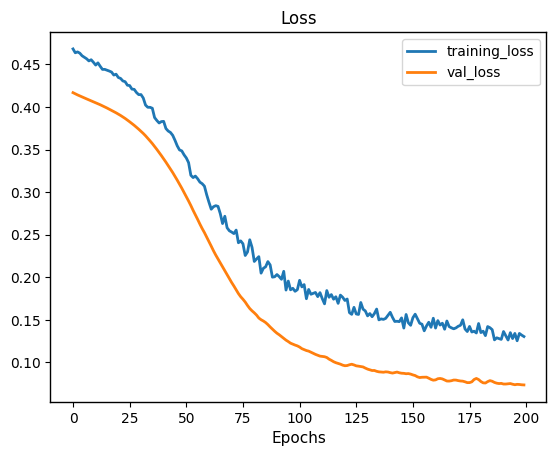

In [162]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=8,     # small batch works better for tiny datasets
    callbacks=[early_stop],
    verbose=1
)

plot_loss_curves(history)

In [163]:
model.summary()

Model: "GRU_Water"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 64)             │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 120)            │         3,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_7 (Reshape)             │ (None, 60, 2)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,594 (232.79 KB)

 Trainable params: 19,864 (77.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 39,730 (155.20 KB)

In [164]:
y_pred = model.predict(X_test)

# Inverse transform
y_pred =y_inverse_scaling(y_pred,y_Water_scalers_monthly,target_Water_cols)
y_test_original =y_inverse_scaling(y_test,y_Water_scalers_monthly,target_Water_cols)

n_targets = len(target_Water_cols)

y_pred_scaled = y_pred.reshape(-1, output_steps, n_targets)
y_test_scaled = y_test_original.reshape(-1, output_steps, n_targets)

y_pred_inv = []
y_true_inv = []
metrics = {}

for j, var in enumerate(target_Water_cols):

    idx = feature_Water_cols.index(var)

    # Empty arrays for inverse transform
    temp_pred = np.zeros((y_pred_scaled.shape[0] * output_steps, len(feature_Water_cols)))
    temp_true = np.zeros((y_test_scaled.shape[0] * output_steps, len(feature_Water_cols)))

    # Fill values
    temp_pred[:, idx] = y_pred_scaled[:, :, j].flatten()
    temp_true[:, idx] = y_test_scaled[:, :, j].flatten()

    y_pred_inv.append(temp_pred)#pred_inv
    y_true_inv.append(temp_true)#true_inv

    # Metrics
    rmse = np.sqrt(mean_squared_error(temp_true,temp_pred))#true_inv, pred_inv
    mae = mean_absolute_error(temp_true,temp_pred)
    r2 = r2_score(temp_true,temp_pred)
    # ---- MASE ----
    naive_errors = np.abs(temp_true[1:] - temp_true[:-1])
    mae_naive = np.mean(naive_errors)
    mase = mae / mae_naive if mae_naive != 0 else np.nan

    metrics[var] ={
        "R2": r2,
        "RMSE": rmse,#exemple: T2MDEW => RMSE: 1.3684 means the prediction is wrong by about 1°C on average => exemple: If the real dew point is 12°C, the model predicts something like 11°C or 13°C
        "MAE": mae,
        "MASE": mase
    }

    #print(f"{var} => R2: {r2:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}") #MASE: {mase:.4f}
df_metrics_Water = pd.DataFrame(metrics).T
df_metrics_Water

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step


,R2,RMSE,MAE,MASE
QV2M,0.976773,0.318774,0.102966,0.581524
T2MDEW,0.965315,0.481743,0.148335,0.593050


In [157]:
metrics

{'QV2M': {'R2': 0.9793937541695893,
  'RMSE': np.float64(0.30025435157326014),
  'MAE': 0.09765762005412675,
  'MASE': np.float64(0.06507315012924975)},
 'T2MDEW': {'R2': 0.9655663665468907,
  'RMSE': np.float64(0.479996373629148),
  'MAE': 0.14832247932907788,
  'MASE': np.float64(0.09883315771543592)}}

In [169]:
metrics_models_preformans.append({"GRU":metrics})

In [170]:
metrics_models_preformans

[{'LSTM': {'QV2M': {'R2': 0.973597532714709,
    'RMSE': np.float64(0.33986944992182866),
    'MAE': 0.11080017550028655,
    'MASE': np.float64(0.6257683858766968)},
   'T2MDEW': {'R2': 0.9583374043706933,
    'RMSE': np.float64(0.5279826993164112),
    'MAE': 0.16176882840449489,
    'MASE': np.float64(0.6467579642733902)}}},
 {'CNN': {'QV2M': {'R2': 0.8303690855061506,
    'RMSE': np.float64(0.8614743949712199),
    'MAE': 0.30681219228992684},
   'T2MDEW': {'R2': 0.8284055297407372,
    'RMSE': np.float64(1.0715148010496194),
    'MAE': 0.380693607891307}}},
 {'XGBoost': {'QV2M': {'R2': 0.8735963767962391,
    'RMSE': np.float64(0.7436517997700269),
    'MAE': 0.5712111934879083,
    'MASE': np.float64(0.5376734963485467)},
   'T2MDEW': {'R2': 0.7447957632601948,
    'RMSE': np.float64(1.3067438663090054),
    'MAE': 0.97415480595009,
    'MASE': np.float64(0.6491180299252195)}}},
 {'QV2M': {'R2': 0.8763625250175356,
   'RMSE': np.float64(0.7354699544047147),
   'MAE': 0.5859457203

In [93]:
X.shape, X_train.shape , X_test.shape

((83, 48, 6), (66, 48, 6), (17, 48, 6))

###CNN

In [94]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalAveragePooling1D
from tensorflow.keras.layers import Dense, Dropout, Reshape
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)

model_cnn = Sequential([

    Conv1D(64, 3, activation="relu", padding="same", input_shape=(48, 6)),
    Conv1D(64, 3, activation="relu", padding="same"),

    Conv1D(32, 3, activation="relu", padding="same"),

    GlobalAveragePooling1D(),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(output_steps * len(target_Water_cols)),
    Reshape((output_steps, len(target_Water_cols)))
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [95]:
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

In [96]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 490ms/step - loss: 0.4590 - mae: 0.8780 - mse: 0.9847 - val_loss: 0.4155 - val_mae: 0.8185 - val_mse: 0.8829 - learning_rate: 0.0010
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.4555 - mae: 0.8746 - mse: 0.9760 - val_loss: 0.4148 - val_mae: 0.8177 - val_mse: 0.8813 - learning_rate: 0.0010
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4557 - mae: 0.8752 - mse: 0.9762 - val_loss: 0.4148 - val_mae: 0.8179 - val_mse: 0.8815 - learning_rate: 0.0010
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4555 - mae: 0.8750 - mse: 0.9758 - val_loss: 0.4149 - val_mae: 0.8181 - val_mse: 0.8822 - learning_rate: 0.0010
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4558 - mae: 0.8755 - mse: 0.9768 - val_loss: 0.4152 - val_mae: 0.8187 - val_mse: 0.8837 - learning_rate: 0.0010
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4555 - mae: 0.8752 - mse: 0.9767 - val_loss: 0.4157 - val_mae: 0.8195 - val_mse

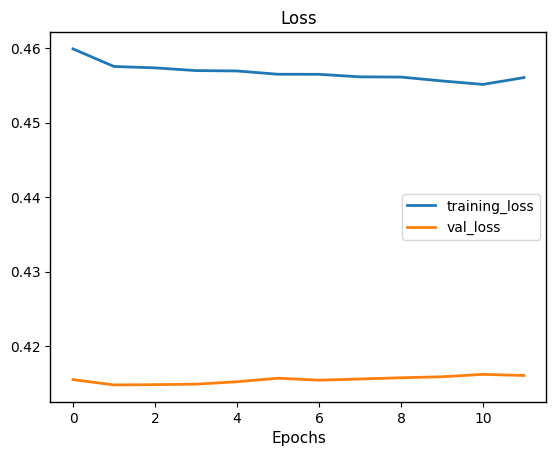

In [97]:
history = model_cnn.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=8,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
plot_loss_curves(history)

In [171]:
y_pred = model_cnn.predict(X_test)

# Inverse transform
y_pred =y_inverse_scaling(y_pred,y_Water_scalers_monthly,target_Water_cols)
y_test_original =y_inverse_scaling(y_test,y_Water_scalers_monthly,target_Water_cols)

n_targets = len(target_Water_cols)

y_pred_scaled = y_pred.reshape(-1, output_steps, n_targets)
y_test_scaled = y_test_original.reshape(-1, output_steps, n_targets)

y_pred_inv = []
y_true_inv = []
metrics = {}

for j, var in enumerate(target_Water_cols):

    idx = feature_Water_cols.index(var)

    # Empty arrays for inverse transform
    temp_pred = np.zeros((y_pred_scaled.shape[0] * output_steps, len(feature_Water_cols)))
    temp_true = np.zeros((y_test_scaled.shape[0] * output_steps, len(feature_Water_cols)))

    # Fill values
    temp_pred[:, idx] = y_pred_scaled[:, :, j].flatten()
    temp_true[:, idx] = y_test_scaled[:, :, j].flatten()

    y_pred_inv.append(temp_pred)#pred_inv
    y_true_inv.append(temp_true)#true_inv

    # Metrics
    rmse = np.sqrt(mean_squared_error(temp_true,temp_pred))#true_inv, pred_inv
    mae = mean_absolute_error(temp_true,temp_pred)
    r2 = r2_score(temp_true,temp_pred)
    # ---- MASE ----
    naive_errors = np.abs(true_flat[1:] - true_flat[:-1])
    mae_naive = np.mean(naive_errors)
    mase = mae / mae_naive if mae_naive != 0 else np.nan

    metrics[var] ={
        "R2": r2,
        "RMSE": rmse,#exemple: T2MDEW => RMSE: 1.3684 means the prediction is wrong by about 1°C on average => exemple: If the real dew point is 12°C, the model predicts something like 11°C or 13°C
        "MAE": mae,
        "MASE":mase
    }

    #print(f"{var} => R2: {r2:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}") #MASE: {mase:.4f}
df_metrics_Water = pd.DataFrame(metrics).T
df_metrics_Water

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


,R2,RMSE,MAE,MASE
QV2M,0.830369,0.861474,0.306812,0.204441
T2MDEW,0.828406,1.071515,0.380694,0.253671


In [174]:
metrics_models_preformans.append({"CNN":metrics})

### XGBoost

#### Prepare Data for XGBoost

In [100]:
import numpy as np

# Flatten time dimension
X_train_xgb = X_train.reshape(X_train.shape[0], -1)
X_test_xgb = X_test.reshape(X_test.shape[0], -1)

print(X_train_xgb.shape)
print(X_test_xgb.shape)

(66, 288)
(17, 288)


In [103]:
y_train_xgb = y_train.reshape(y_train.shape[0], -1)
y_test_xgb = y_test.reshape(y_test.shape[0], -1)

print(y_train_xgb.shape)

(66, 120)


#### Construct XGBoost Model

In [104]:
from xgboost import XGBRegressor # take 4 min
from sklearn.multioutput import MultiOutputRegressor

xgb_model = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
)

xgb_model.fit(X_train_xgb, y_train_xgb)


MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.05, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=4,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None, ...))

In [105]:
y_pred_xgb = xgb_model.predict(X_test_xgb)

In [106]:
y_pred_xgb = y_pred_xgb.reshape(
    y_test.shape[0],
    output_steps,
    len(target_Water_cols)
)

#### Evaluate

In [107]:
# =============================
# Prepare test data correctly
# =============================
X_test_xgb = X_test.reshape(X_test.shape[0], -1)

# =============================
# Predict
# =============================
y_pred = xgb_model.predict(X_test_xgb)

# Reshape back to 3D FIRST
n_targets = len(target_Water_cols)

y_pred = y_pred.reshape(
    y_test.shape[0],
    output_steps,
    n_targets
)

# =============================
# Inverse scaling (NOW correct shape)
# =============================
y_pred = y_inverse_scaling(
    y_pred,
    y_Water_scalers_monthly,
    target_Water_cols
)

y_test_original = y_inverse_scaling(
    y_test,
    y_Water_scalers_monthly,
    target_Water_cols
)


In [108]:
X_test.shape

(17, 48, 6)

In [109]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

metrics = {}

for j, var in enumerate(target_Water_cols):

    pred_flat = y_pred[:, :, j].flatten()
    true_flat = y_test_original[:, :, j].flatten()

    rmse = np.sqrt(mean_squared_error(true_flat, pred_flat))
    mae = mean_absolute_error(true_flat, pred_flat)
    r2 = r2_score(true_flat, pred_flat)

    # ---- MASE ----
    naive_errors = np.abs(true_flat[1:] - true_flat[:-1])
    mae_naive = np.mean(naive_errors)
    mase = mae / mae_naive if mae_naive != 0 else np.nan

    metrics[var] = {
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "MASE": mase
    }

df_metrics_Water = pd.DataFrame(metrics).T
df_metrics_Water

,R2,RMSE,MAE,MASE
QV2M,0.873596,0.743652,0.571211,0.537673
T2MDEW,0.744796,1.306744,0.974155,0.649118


In [110]:
metrics_models_preformans.append({"XGBoost":metrics})

After trying to implement advanced models(like : N_Hits ,TFT ,TCN ,DeepAR ... ), we encountered overfitting and underfitting problems because the dataset we are working with is very small.

The real issue is that the objective of our study is to forecast the next five years.

### TCN

In [111]:
%%capture
!pip install keras-tcn

In [137]:
from tcn import TCN

In [138]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Reshape
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tcn import TCN

tf.random.set_seed(42)

model_tcn = Sequential([

    TCN(
        nb_filters=32,
        kernel_size=3,
        dilations=[1,2,4,8,16],
        padding='causal',
        use_skip_connections=True,
        dropout_rate=0.2,
        return_sequences=True,
        input_shape=(48, 6)
    ),

    TCN(
        nb_filters=16,
        kernel_size=3,
        dilations=[1,2,4],
        padding='causal',
        use_skip_connections=True,
        dropout_rate=0.2,
        return_sequences=False
    ),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(output_steps * len(target_Water_cols)),
    Reshape((output_steps, len(target_Water_cols)))
])

/usr/local/lib/python3.12/dist-packages/tcn/tcn.py:268: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [139]:
model_tcn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)


In [140]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=1e-6
)


In [141]:
history = model_tcn.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=400,
    batch_size=8,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/400
9/9 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - loss: 20.4965 - mae: 20.9910 - mse: 765.8293 - val_loss: 6.3782 - val_mae: 6.8621 - val_mse: 75.1124 - learning_rate: 2.0000e-04
Epoch 2/400
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 13.7651 - mae: 14.2566 - mse: 344.0732 - val_loss: 3.9498 - val_mae: 4.4233 - val_mse: 31.4796 - learning_rate: 2.0000e-04
Epoch 3/400
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 10.8270 - mae: 11.3164 - mse: 229.1431 - val_loss: 2.5947 - val_mae: 3.0565 - val_mse: 15.1548 - learning_rate: 2.0000e-04
Epoch 4/400
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 8.0695 - mae: 8.5539 - mse: 133.0016 - val_loss: 1.7940 - val_mae: 2.2457 - val_mse: 8.2045 - learning_rate: 2.0000e-04
Epoch 5/400
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 5.3396 - mae: 5.8185 - mse: 60.0162 - val_loss: 1.3896 - val_mae: 1.8289 - val_mse: 5.4225 - learning_rate: 2.0000e-04
Epoch 6/400
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.5318 - mae: 5.0067 - mse: 45.7156 - val_los

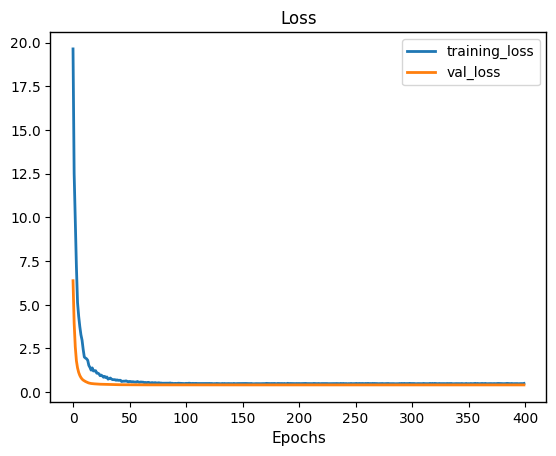

In [142]:
plot_loss_curves(history)

In [149]:
y_pred = model_tcn.predict(X_test)

# Inverse transform
y_pred =y_inverse_scaling(y_pred,y_Water_scalers_monthly,target_Water_cols)
y_test_original =y_inverse_scaling(y_test,y_Water_scalers_monthly,target_Water_cols)

n_targets = len(target_Water_cols)

y_pred_scaled = y_pred.reshape(-1, output_steps, n_targets)
y_test_scaled = y_test_original.reshape(-1, output_steps, n_targets)

y_pred_inv = []
y_true_inv = []
metrics = {}

for j, var in enumerate(target_Water_cols):

    idx = feature_Water_cols.index(var)

    # Empty arrays for inverse transform
    temp_pred = np.zeros((y_pred_scaled.shape[0] * output_steps, len(feature_Water_cols)))
    temp_true = np.zeros((y_test_scaled.shape[0] * output_steps, len(feature_Water_cols)))

    # Fill values
    temp_pred[:, idx] = y_pred_scaled[:, :, j].flatten()
    temp_true[:, idx] = y_test_scaled[:, :, j].flatten()

    y_pred_inv.append(temp_pred) #pred_inv
    y_true_inv.append(temp_true) #true_inv

    # Metrics
    rmse = np.sqrt(mean_squared_error(temp_true,temp_pred))#true_inv, pred_inv
    mae = mean_absolute_error(temp_true,temp_pred)
    r2 = r2_score(temp_true,temp_pred)
    # ---- MASE ----
    naive_errors = np.abs(true_flat[1:] - true_flat[:-1])
    mae_naive = np.mean(naive_errors)
    mase = mae / mae_naive if mae_naive != 0 else np.nan

    metrics[var] ={
        "R2": r2,
        "RMSE": rmse, #exemple: T2MDEW => RMSE: 1.3684 means the prediction is wrong by about 1°C on average => exemple: If the real dew point is 12°C, the model predicts something like 11°C or 13°C
        "MAE": mae,
        "MASE": mase
    }

    #print(f"{var} => R2: {r2:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}") #MASE: {mase:.4f}
df_metrics_Water = pd.DataFrame(metrics).T
df_metrics_Water

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


,R2,RMSE,MAE,MASE
QV2M,0.830684,0.860674,0.306130,0.203986
T2MDEW,0.826394,1.077776,0.383487,0.255533


In [145]:
y_pred.shape

(17, 60, 2)

In [155]:
metrics_models_preformans.append({"TCN_Model":metrics})

In [123]:
y_pred.shape,y_test.shape

((17, 60, 2), (17, 60, 2))

## LSTM Imporvement

In [176]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, LayerNormalization, Reshape
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)

model = Sequential([

    LSTM(
        128,
        return_sequences=True,
        input_shape=(input_steps, len(feature_Water_cols))
    ),
    LayerNormalization(),

    LSTM(64),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(output_steps * len(target_Water_cols)),
    Reshape((output_steps, len(target_Water_cols)))

], name="Optimized_LSTM_Water")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=1e-6
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 185ms/step - loss: 0.4732 - mae: 0.8905 - mse: 1.0307 - val_loss: 0.4144 - val_mae: 0.8155 - val_mse: 0.8867 - learning_rate: 2.0000e-04
Epoch 2/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.4633 - mae: 0.8799 - mse: 1.0039 - val_loss: 0.4086 - val_mae: 0.8088 - val_mse: 0.8726 - learning_rate: 2.0000e-04
Epoch 3/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.4550 - mae: 0.8702 - mse: 0.9839 - val_loss: 0.4026 - val_mae: 0.8015 - val_mse: 0.8581 - learning_rate: 2.0000e-04
Epoch 4/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.4490 - mae: 0.8627 - mse: 0.9705 - val_loss: 0.3974 - val_mae: 0.7953 - val_mse: 0.8452 - learning_rate: 2.0000e-04
Epoch 5/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.4437 - mae: 0.8559 - mse: 0.9578 - val_loss: 0.3933 - val_mae: 0.7903 - val_mse: 0.8355 - learning_rate: 2.0000e-04
Epoch 6/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - loss: 0.4413 - mae: 0.8533 - mse: 0.9515 - val_loss: 0.3892 

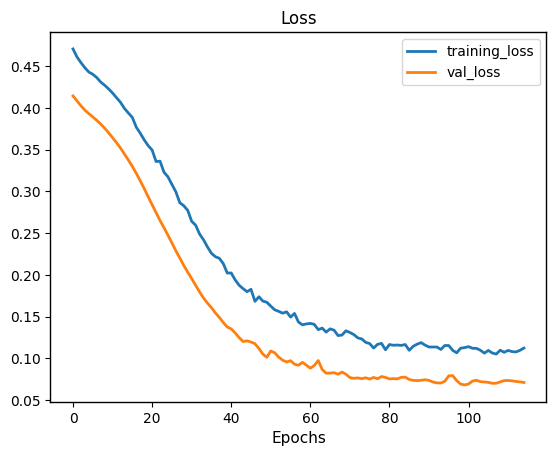

In [177]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=1000,
    batch_size=16,   # ⬅️ recommandé
    verbose=1,
    callbacks=[
        create_model_checkpoint(model.name),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            min_delta=1e-4,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-5,
            verbose=1
        )
    ]
)
plot_loss_curves(history)

In [184]:
y_pred = model.predict(X_test)

# Inverse transform
y_pred =y_inverse_scaling(y_pred,y_Water_scalers_monthly,target_Water_cols)
y_test_original =y_inverse_scaling(y_test,y_Water_scalers_monthly,target_Water_cols)

n_targets = len(target_Water_cols)

y_pred_scaled = y_pred.reshape(-1, output_steps, n_targets)
y_test_scaled = y_test_original.reshape(-1, output_steps, n_targets)

y_pred_inv = []
y_true_inv = []
metrics = {}

for j, var in enumerate(target_Water_cols):

    pred_flat = y_pred[:, :, j].flatten()
    true_flat = y_test_original[:, :, j].flatten()

    rmse = np.sqrt(mean_squared_error(true_flat, pred_flat))
    mae = mean_absolute_error(true_flat, pred_flat)
    r2 = r2_score(true_flat, pred_flat)

    # ---- MASE ----
    naive_errors = np.abs(true_flat[1:] - true_flat[:-1])
    mae_naive = np.mean(naive_errors)
    mase = mae / mae_naive if mae_naive != 0 else np.nan

    metrics[var] = {
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "MASE": mase
    }

df_metrics_Water = pd.DataFrame(metrics).T
df_metrics_Water

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 856ms/step


,R2,RMSE,MAE,MASE
QV2M,0.880139,0.724150,0.569563,0.536122
T2MDEW,0.797915,1.162824,0.871335,0.580605


In [185]:
metrics

{'QV2M': {'R2': 0.8801392231953108,
  'RMSE': np.float64(0.7241498015829406),
  'MAE': 0.5695628896222441,
  'MASE': np.float64(0.5361219698508167)},
 'T2MDEW': {'R2': 0.7979145559308105,
  'RMSE': np.float64(1.1628241606305714),
  'MAE': 0.8713350893656413,
  'MASE': np.float64(0.5806051698960855)}}

In [189]:
metrics_models_preformans.append({"LSTM_Improvement":metrics})

## Comparison

In [191]:
import pandas as pd
import numpy as np

# Assuming the last element corresponds to the 'Optimized_LSTM' model
model_names = ['LSTM', 'GRU', 'CNN', 'XGBoost', 'TCN_Model', 'Optimized_LSTM']

all_metrics_data = []

for i, model_entry in enumerate(metrics_models_preformans):
    if len(model_entry) == 1: # Standard entry like {'LSTM': {...}}
        model_name = list(model_entry.keys())[0]
        metrics_by_target = model_entry[model_name]
    else: # Last entry like {'QV2M': {...}, 'T2MDEW': {...}}
        model_name = model_names[i] # Use the corresponding name from the pre-defined list
        metrics_by_target = model_entry

    for target_var, metrics in metrics_by_target.items():
        row = {
            'Model': model_name,
            'Target': target_var
        }
        for metric_name, value in metrics.items():
            row[metric_name] = value.item() if isinstance(value, np.generic) else value
        all_metrics_data.append(row)

df_performance = pd.DataFrame(all_metrics_data)

df_performance

,Model,Target,R2,RMSE,MAE,MASE
0,LSTM,QV2M,0.973598,0.339869,0.110800,0.625768
1,LSTM,T2MDEW,0.958337,0.527983,0.161769,0.646758
2,XGBoost,QV2M,0.873596,0.743652,0.571211,0.537673
3,XGBoost,T2MDEW,0.744796,1.306744,0.974155,0.649118
4,CNN,QV2M,0.876363,0.735470,0.585946,0.551543
5,CNN,T2MDEW,0.793398,1.175746,0.889935,0.592999
6,GRU,QV2M,0.976773,0.318774,0.102966,0.581524
7,GRU,T2MDEW,0.965315,0.481743,0.148335,0.593050
8,CNN,QV2M,0.830369,0.861474,0.306812,0.204441
9,CNN,T2MDEW,0.828406,1.071515,0.380694,0.253671


In [194]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Data
data = {
    "Model": [
        "LSTM","LSTM",
        "XGBoost","XGBoost",
        "CNN","CNN",
        "GRU","GRU",
        "CNN_v2","CNN_v2",
        "LSTM_Improvement","LSTM_Improvement"
    ],
    "Target": [
        "QV2M","T2MDEW",
        "QV2M","T2MDEW",
        "QV2M","T2MDEW",
        "QV2M","T2MDEW",
        "QV2M","T2MDEW",
        "QV2M","T2MDEW"
    ],
    "R2": [0.973598,0.958337,0.873596,0.744796,0.876363,0.793398,
           0.976773,0.965315,0.830369,0.828406,0.880139,0.797915],
    "RMSE": [0.339869,0.527983,0.743652,1.306744,0.735470,1.175746,
             0.318774,0.481743,0.861474,1.071515,0.724150,1.162824],
    "MAE": [0.110800,0.161769,0.571211,0.974155,0.585946,0.889935,
            0.102966,0.148335,0.306812,0.380694,0.569563,0.871335],
    "MASE": [0.625768,0.646758,0.537673,0.649118,0.551543,0.592999,
             0.581524,0.593050,0.204441,0.253671,0.536122,0.580605]
}

df = pd.DataFrame(data)

metrics = ["R2", "RMSE", "MAE", "MASE"]
targets = ["QV2M", "T2MDEW"]

# Create subplot (2 rows: one per target)
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=["QV2M Performance", "T2MDEW Performance"],
    vertical_spacing=0.12
)

for i, target in enumerate(targets, start=1):
    df_target = df[df["Target"] == target]

    for metric in metrics:
        fig.add_trace(
            go.Bar(
                x=df_target["Model"],
                y=df_target[metric],
                name=metric,
                legendgroup=metric,
                showlegend=(i == 1)  # Show legend only once
            ),
            row=i, col=1
        )

fig.update_layout(
    height=900,
    width=1100,
    title="Model Comparison by Target Variable",
    barmode="group"
)

fig.update_xaxes(title_text="Model")
fig.update_yaxes(title_text="Metric Value")

fig.show()

# Energie Parameters Forecasting

## LSTM & CNN

In [195]:
Energie_metrics_models_performances=[]

In [196]:
target_indices = [feature_Energie_cols.index(var) for var in target_Energie_cols]
data = X_Energie_scaled.values

In [197]:
target_indices,feature_Energie_cols

([4, 5],
 ['WS50M',
  'ALLSKY_SFC_SW_DIFF',
  'CLRSKY_SFC_SW_DWN',
  'ALLSKY_SFC_SW_DNI',
  'ALLSKY_SFC_SW_DWN',
  'WS10M'])

In [198]:
def create_sequences(data, input_steps, output_steps, target_indices):
    X, y = [], []
    for i in range(len(data) - input_steps - output_steps):
        X.append(data[i : i + input_steps])

        # y shape → (output_steps, n_targets)
        future = data[i + input_steps : i + input_steps + output_steps, target_indices]
        y.append(future)

    return np.array(X), np.array(y)

In [199]:
input_steps = WINDOW_SIZE # 48 month
output_steps = HORIZON # 60 month

#sliding-window
X, y = create_sequences(data, input_steps, output_steps, target_indices) #X -> past 60 days of all features and y -> next 30 days of QV2M only

# y_flat = y.reshape(y.shape[0], -1)

#Split data into Train/Test splits
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:] # :split=first 80% for training and split:=last 20% for test
y_train, y_test = y[:split], y[split:]

In [200]:
X_train.shape, X_test.shape,y_train.shape, y_test.shape

((66, 48, 6), (17, 48, 6), (66, 60, 2), (17, 60, 2))

In [201]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, LSTM, Dense, Dropout,
    BatchNormalization, Reshape, GaussianNoise
)
from tensorflow.keras.regularizers import l2
tf.random.set_seed(42)
model = Sequential([
    Input(shape=(input_steps, len(feature_Energie_cols))),

    # ===== Anti-overfitting at input =====
    GaussianNoise(0.01),

    # ===== Local temporal patterns =====
    Conv1D(
        filters=32,               # ↓ reduced
        kernel_size=5,
        padding="causal",
        activation="relu",
        kernel_regularizer=l2(5e-4)
    ),
    BatchNormalization(),
    Dropout(0.2),

    # ===== LSTM stack =====
    LSTM(
        96,                       # ↓ reduced
        return_sequences=True,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(5e-4)
    ),
    Dropout(0.35),

    LSTM(
        48,                       # ↓ reduced
        return_sequences=False,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(5e-4)
    ),
    Dropout(0.35),

    # ===== Projection =====
    Dense(32, activation="relu"),
    Dropout(0.35),

    Dense(output_steps * len(target_Energie_cols)),
    Reshape((output_steps, len(target_Energie_cols)))
], name="Energy_ConvLSTM_AntiOverfit")

def hybrid_energy_horizon_loss(y_true, y_pred):
    # Huber
    huber = tf.keras.losses.Huber(delta=1.0)(y_true, y_pred)

    # erreur relative
    rel = tf.abs(y_true - y_pred) / (tf.abs(y_true) + 1e-3)
    rel = tf.reduce_mean(rel)

    # poids horizon croissant
    horizon = tf.shape(y_true)[1]
    time_weights = tf.linspace(0.5, 2.0, horizon)
    time_weights = tf.reshape(time_weights, (1, horizon, 1))

    return tf.reduce_mean(huber * time_weights) + 0.3 * rel
# def energy_day_masked_loss(y_true, y_pred):
#     # masque jour (ex: DNI > 10)
#     mask = tf.cast(y_true > 10.0, tf.float32)

#     huber = tf.keras.losses.Huber(delta=1.0)(y_true, y_pred)

#     loss = tf.reduce_sum(huber * mask) / (tf.reduce_sum(mask) + 1e-6)
#     return loss

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4
    ),
    loss="mae",#hybrid_energy_horizon_loss
    metrics=["mae",
             tf.keras.metrics.RootMeanSquaredError(name="rmse")
             ]
)


In [202]:
model.summary()

Model: "Energy_ConvLSTM_AntiOverfit"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 48, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 48, 32)         │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 48, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 48, 96)         │        49,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 48, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 48)             │        27,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 120)            │         3,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_9 (Reshape)             │ (None, 60, 2)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,024 (328.22 KB)

 Trainable params: 83,960 (327.97 KB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
# # Training
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=1000,
    batch_size=16,   # ⬅️ recommandé
    verbose=1,
    callbacks=[
        create_model_checkpoint(model.name),
        tf.keras.callbacks.EarlyStopping(
                                        monitor="val_loss",
                                        patience=10,
                                        restore_best_weights=True,
                                        min_delta=1e-3
                                        ),
        tf.keras.callbacks.ReduceLROnPlateau(
                                        monitor="val_loss",
                                        factor=0.3,
                                        patience=5,
                                        min_lr=1e-5
                                        )
    ]
)
plot_loss_curves(history)

In [204]:
model.name

'Energy_ConvLSTM_AntiOverfit'

In [205]:
model = tf.keras.models.load_model(
    colab_saved_models+f"/LSTM_Model_Energie_Monthly.keras",
    custom_objects={"hybrid_energy_horizon_loss": hybrid_energy_horizon_loss}
)

In [206]:
y_pred = model.predict(X_test)

# Inverse transform
y_pred =y_inverse_scaling(y_pred,y_Energie_scalers_monthly,target_Energie_cols)
y_test_original =y_inverse_scaling(y_test,y_Energie_scalers_monthly,target_Energie_cols)

n_targets = len(target_Energie_cols)

y_pred_scaled = y_pred.reshape(-1, output_steps, n_targets)
y_test_scaled = y_test_original.reshape(-1, output_steps, n_targets)

y_pred_inv = []
y_true_inv = []
metrics = {}

for j, var in enumerate(target_Energie_cols):

    idx = feature_Energie_cols.index(var)

    # Empty arrays for inverse transform
    temp_pred = np.zeros((y_pred_scaled.shape[0] * output_steps, len(feature_Energie_cols)))
    temp_true = np.zeros((y_test_scaled.shape[0] * output_steps, len(feature_Energie_cols)))

    # Fill values
    temp_pred[:, idx] = y_pred_scaled[:, :, j].flatten()
    temp_true[:, idx] = y_test_scaled[:, :, j].flatten()


    y_pred_inv.append(temp_pred)#pred_inv
    y_true_inv.append(temp_true)#true_inv

    # Metrics
    rmse = np.sqrt(mean_squared_error(temp_true,temp_pred))#true_inv, pred_inv
    mae = mean_absolute_error(temp_true,temp_pred)
    r2 = r2_score(temp_true,temp_pred)
    # ---- MASE ----
    naive_errors = np.abs(true_flat[1:] - true_flat[:-1])
    mae_naive = np.mean(naive_errors)
    mase = mae / mae_naive if mae_naive != 0 else np.nan

    metrics[var] ={
        "R2": r2,
        "RMSE": rmse,#exemple: T2MDEW => RMSE: 1.3684 means the prediction is wrong by about 1°C on average => exemple: If the real dew point is 12°C, the model predicts something like 11°C or 13°C
        "MAE": mae,
        "MASE": mase
    }

    #print(f"{var} => R2: {r2:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}") #MASE: {mase:.4f}
df_metrics = pd.DataFrame(metrics).T
df_metrics

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


,R2,RMSE,MAE,MASE
ALLSKY_SFC_SW_DWN,0.972717,25.606668,7.234966,4.820945
WS10M,0.861233,0.243166,0.076294,0.050838


In [ ]:
y_test_original[-9:,-1,:],y_pred[-9:,-1,:]

### Prediction Plot

> ALLSKY_SFC_SW_DWN

In [ ]:
y_train_original =y_inverse_scaling(y_train,
                                    y_Energie_scalers_monthly,
                                    target_Energie_cols
                                   )

In [ ]:
residuals = y_test_original[:,:,0] - y_pred[:,:,0]
sigma = np.std(residuals, axis=0)  # per horizon

In [ ]:
z = 1.96  # 95% confidence

lower_ci = y_pred[:,:,0] - z * sigma
upper_ci = y_pred[:,:,0] + z * sigma

In [ ]:
col = 0

In [ ]:
y_pred[-1,-1,-5:],y_test_original[-1,-1,-5:], y_train_original[-1,-1,-5:]

In [ ]:
import plotly.graph_objects as go
import pandas as pd

# =========================
# 1. CREATE MONTHLY TIME AXIS WITH 83 POINTS ENDING IN 2025
# =========================
n_total = y_train_original.shape[0] + y_test_original.shape[0]  # 66 + 17 = 83
last_month = pd.Timestamp("2025-12-31")
X_time = pd.date_range(end=last_month, periods=n_total, freq="ME")

n_train = y_train_original.shape[0]  # 66
n_test = y_test_original.shape[0]  # 17

X_train_time = X_time[:n_train]
X_test_time = X_time[n_train:]

# =========================
# 2. EXTRACT DATA FOR HORIZON h
# =========================
h = 0
train_vals = y_train_original[:, h, col]      # shape: (66,)
test_vals  = y_test_original[:, h, col]       # shape: (17,)
pred_vals  = y_pred[:, h, col]                # shape: (17,)
ci_low     = lower_ci[:, h]                 # shape: (17,)
ci_high    = upper_ci[:, h]                 # shape: (17,)

# =========================
# 3. ADD LAST TRAIN VALUE TO TEST & PRED FOR CONTINUITY
# =========================
# Last train timestamp and value
last_train_time = X_train_time[-1]
last_train_val = train_vals[-1]

# Extended time axis for test (includes last train point)
X_test_extended = pd.DatetimeIndex([last_train_time]).append(X_test_time)

# Extend test and prediction arrays
test_vals_extended = np.concatenate([[last_train_val], test_vals])
pred_vals_extended = np.concatenate([[last_train_val], pred_vals])

# For CI: we usually don't show CI at the衔接 point (it's observed, not predicted)
# So CI stays aligned with original X_test_time (no prepend)

# =========================
# 4. PLOT
# =========================
fig = go.Figure()

# Train (up to last point)
fig.add_trace(go.Scatter(
    x=X_train_time,
    y=train_vals,
    mode='lines',
    name='Train',
    line=dict(color='black', width=2)
))

# Test (starting from last train point)
fig.add_trace(go.Scatter(
    x=X_test_extended,
    y=test_vals_extended,
    mode='lines',
    name='Test',
    line=dict(color='blue', width=2)
))

# Prediction (starting from last train point)
fig.add_trace(go.Scatter(
    x=X_test_extended,
    y=pred_vals_extended,
    mode='lines',
    name='Prediction',
    line=dict(color='red', dash='dash', width=2)
))

# Confidence Interval (only over forecast horizon, not the衔接 point)
fig.add_trace(go.Scatter(
    x=X_test_time.tolist() + X_test_time[::-1].tolist(),
    y=ci_high.tolist() + ci_low[::-1].tolist(),
    fill='toself',
    fillcolor='rgba(173,216,230,0.3)',
    line=dict(color='rgba(255,255,255,0)'),
    showlegend=False,
    name='95% CI'
))

# Layout
fig.update_layout(
    title=f"Monthly Forecast Ending in 2025 – Horizon {h}",
    xaxis_title="Date",
    yaxis_title="ALLSKY_SKY_SW_DNI",
    xaxis=dict(
        tickformat="%Y-%m",
        dtick="M12",
        showgrid=True,
        range=[X_time[0] - pd.DateOffset(months=2), X_time[-1] + pd.DateOffset(months=2)]
    ),
    yaxis=dict(showgrid=True),
    template="plotly_white",
    width=1100,
    height=500
)

fig.show()

In [ ]:
df.columns

In [ ]:
df_monthly["ALLSKY_SFC_SW_DWN"].min()

In [ ]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# =========================
# 1. DATA & DYNAMIC TIME AXIS
# =========================
n_train = 66
n_test = 17 # This is your current test size
X_time = pd.date_range(end=pd.Timestamp("2025-12-31"), periods=n_train + n_test, freq="ME")

X_train_time = X_time[:n_train]
X_test_time = X_time[n_train:]

h, col = 0, 0
train_vals = y_train_original[:, h, col]
pred_vals = y_pred[:, h, col]
col_name = "ALLSKY_SFC_SW_DWN"
Error = metrics["ALLSKY_SFC_SW_DWN"]["MAE"]

# --- DYNAMIC BACKFILL & END TRACKING ---
start_view_date = pd.Timestamp("2024-06-01")

# 1. Get Historical part (From 06-2024 to end of training)
hist_mask = X_train_time >= start_view_date
hist_time = X_train_time[hist_mask]
hist_vals = train_vals[hist_mask]

# 2. Combine with Full Prediction
full_pred_time = hist_time.append(X_test_time)
full_pred_vals = np.concatenate([hist_vals, pred_vals])

# 3. Create Error Mask (0 for history, RMSE for forecast)
error_values = ([0] * len(hist_vals)) + ([Error] * len(pred_vals))

# Calculate Y-limits based on the visible window
y_min = full_pred_vals.min() - (Error * 2)
y_max = full_pred_vals.max() + (Error * 2)

# =========================
# 2. PLOT CONFIGURATION
# =========================
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=full_pred_time,
    y=full_pred_vals,
    mode='lines+markers',
    name='Prediction (incl. History)',
    line=dict(color='red', width=2, dash='dash'),
    marker=dict(size=6, color='red'),
    error_y=dict(
        type='data',
        array=error_values,
        symmetric=True,
        color='blue',
        thickness=1.2,
        width=4
    )
))
start_view_date = pd.Timestamp("2024-06-01")
end_view_date = full_pred_time[-1]
#

fig.update_layout(
    # Background & Font
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    font=dict(family="Arial", size=18, color="black"),

    xaxis=dict(
        title=dict(text="Date", font=dict(size=22)),
        linecolor='black',
        linewidth=2,
        mirror=True,
        showgrid=False,
        # SETTING THE SPECIFIC RANGE HERE
        range=[start_view_date, end_view_date],
        tickformat="%m-%Y", # Format as MM-YYYY for clarity
        dtick="M2",         # Show a tick every 2 months to prevent overlapping
        ticks="outside",
        tickwidth=2,
        tickangle=0         # Keep horizontal for readability
    ),
    yaxis=dict(
        title=dict(text=col_name, font=dict(size=22)),
        linecolor='black',
        linewidth=2,
        mirror=True,
        showgrid=False,
        # Dynamic range based on data visible in this window
        range=[full_pred_vals.min() - (Error*1.5), full_pred_vals.max() + (Error*1.5)],
        ticks="outside",
        tickwidth=2
    ),

    # Legend & Dimensions
    legend=dict(
        orientation="h",
        yanchor="bottom", y=1.05,
        xanchor="right", x=1,
        font=dict(size=16)
    ),
    width=1100,
    height=600,
    margin=dict(l=80, r=40, t=100, b=80),
    template="plotly_white"
)
fig.show()

In [ ]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# =========================
# 1. CREATE MONTHLY TIME AXIS
# =========================
n_train = 66
n_test = 17
n_total = n_train + n_test
last_month = pd.Timestamp("2025-12-31")
X_time = pd.date_range(end=last_month, periods=n_total, freq="ME")

X_train_time = X_time[:n_train]
X_test_time = X_time[n_train:]

# =========================
# 2. EXTRACT DATA FOR HORIZON h
# =========================
h = 0
train_vals = y_train_original[:, h, 0]
test_vals  = y_test_original[:, h, 0]
pred_vals  = y_pred[:, h, 0]
col_name="ALLSKY_SFC_SW_DWN"
Error = metrics["ALLSKY_SFC_SW_DWN"]["RMSE"]
# =========================
# 3. PREPARE CONTINUITY
# =========================
last_train_val = train_vals[-1]
last_train_time = X_train_time[-1]

# Extended arrays for a continuous graph
X_test_extended = pd.DatetimeIndex([last_train_time]).append(X_test_time)
pred_vals_extended = np.concatenate([[last_train_val], pred_vals])

# Error bars usually only apply to actual predictions (not the connection point)
# We create a list for error bars that is 0 at the start (the connection point)
# and the fixed value for the rest.

# Change the multiplier (e.g., 0.5) to make the bars shorter or taller
reduction_factor = 0.6

# 3. Create Error Mask (0 for history, reduced Error for forecast)
error_values = ([0] * len(hist_vals)) + ([Error * reduction_factor] * len(pred_vals))
# error_values = [0] + [Error] * len(pred_vals)

# =========================
# 4. FULL PLOT
# =========================
fig = go.Figure()

# --- Train Trace ---
fig.add_trace(go.Scatter(
    x=X_train_time,
    y=train_vals,
    mode='lines',
    name='Train',
    line=dict(color='black', width=2)
))

# --- Prediction Trace (Now Continuous with Training) ---
fig.add_trace(go.Scatter(
    x=X_test_extended,       # Use extended time
    y=pred_vals_extended,    # Use extended values
    mode='lines+markers',
    name='Prediction',
    line=dict(color='red', width=2, dash='dash'),
    marker=dict(size=8, color='red', symbol='circle'),
    error_y=dict(
        type='data',         # Changed to 'data' to allow 0 at the first point
        array=error_values,  # Full interval
        symmetric=True,
        color='blue',
        thickness=1.5,
        width=6
    )
))

start_view_date = pd.Timestamp("2024-06-01")
end_view_date = full_pred_time[-1]

fig.update_layout(
    # Background & Font
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    font=dict(family="Arial", size=18, color="black"),

    xaxis=dict(
        title=dict(text="Date", font=dict(size=22)),
        linecolor='black',
        linewidth=2,
        mirror=True,
        showgrid=False,
        # SETTING THE SPECIFIC RANGE HERE
        range=[start_view_date, end_view_date],
        tickformat="%m-%Y", # Format as MM-YYYY for clarity
        dtick="M2",         # Show a tick every 2 months to prevent overlapping
        ticks="outside",
        tickwidth=2,
        tickangle=0         # Keep horizontal for readability
    ),
    yaxis=dict(
        title=dict(text=col_name, font=dict(size=22)),
        linecolor='black',
        linewidth=2,
        mirror=True,
        showgrid=False,
        # Dynamic range based on data visible in this window
        # range=[full_pred_vals.min() - (Error*1.5), full_pred_vals.max() + (Error*1.5)],
        ticks="outside",
        tickwidth=2
    ),

    # Legend & Dimensions
    legend=dict(
        orientation="h",
        yanchor="bottom", y=1.05,
        xanchor="right", x=1,
        font=dict(size=16)
    ),
    width=1100,
    height=600,
    margin=dict(l=80, r=40, t=100, b=80),
    template="plotly_white"
)
# plot_name= "[ALLSKY_SFC_SW_DNI-Energie]Prediction_plot.png"
# fig.write_image(plot_name, width=1100, height=600, scale=8)
# files.download(f"{plot_name}")

fig.show()

> `WS10M`

In [ ]:
metrics["WS10M"]["MAE"]

In [ ]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# =========================
# 1. DATA & DYNAMIC TIME AXIS
# =========================
n_train = 66
n_test = 17 # This is your current test size
X_time = pd.date_range(end=pd.Timestamp("2025-12-31"), periods=n_train + n_test, freq="ME")

X_train_time = X_time[:n_train]
X_test_time = X_time[n_train:]

h, col = 0, 1
train_vals = y_train_original[:, h, col]
pred_vals = y_pred[:, h, col]
col_name = "WS10M"
Error = metrics["WS10M"]["MAE"]

# --- DYNAMIC BACKFILL & END TRACKING ---
start_view_date = pd.Timestamp("2024-06-01")

# 1. Get Historical part (From 06-2024 to end of training)
hist_mask = X_train_time >= start_view_date
hist_time = X_train_time[hist_mask]
hist_vals = train_vals[hist_mask]

# 2. Combine with Full Prediction
full_pred_time = hist_time.append(X_test_time)
full_pred_vals = np.concatenate([hist_vals, pred_vals])

# 3. Create Error Mask (0 for history, RMSE for forecast)
# Change the multiplier (e.g., 0.5) to make the bars shorter or taller
reduction_factor = 0.5

# 3. Create Error Mask (0 for history, reduced Error for forecast)
error_values = ([0] * len(hist_vals)) + ([Error * reduction_factor] * len(pred_vals))

# Calculate Y-limits based on the visible window
y_min = full_pred_vals.min() - (Error * 2)
y_max = full_pred_vals.max() + (Error * 2)

# =========================
# 2. PLOT CONFIGURATION
# =========================
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=full_pred_time,
    y=full_pred_vals,
    mode='lines+markers',
    name='Prediction (incl. History)',
    line=dict(color='red', width=2, dash='dash'),
    marker=dict(size=6, color='red'),
    error_y=dict(
        type='data',
        array=error_values,
        symmetric=True,
        color='blue',
        thickness=1.2,
        width=4
    )
))
start_view_date = pd.Timestamp("2024-06-01")
end_view_date = full_pred_time[-1]
#

fig.update_layout(
    # Background & Font
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    font=dict(family="Arial", size=18, color="black"),

    xaxis=dict(
        title=dict(text="Date", font=dict(size=22)),
        linecolor='black',
        linewidth=2,
        mirror=True,
        showgrid=False,
        # SETTING THE SPECIFIC RANGE HERE
        range=[start_view_date, end_view_date],
        tickformat="%m-%Y", # Format as MM-YYYY for clarity
        dtick="M2",         # Show a tick every 2 months to prevent overlapping
        ticks="outside",
        tickwidth=2,
        tickangle=0         # Keep horizontal for readability
    ),
    yaxis=dict(
        title=dict(text=col_name, font=dict(size=22)),
        linecolor='black',
        linewidth=2,
        mirror=True,
        showgrid=False,
        # Dynamic range based on data visible in this window
        range=[full_pred_vals.min() - (Error*1.5), full_pred_vals.max() + (Error*1.5)],
        ticks="outside",


        tickwidth=2
    ),

    # Legend & Dimensions
    legend=dict(
        orientation="h",
        yanchor="bottom", y=1.05,
        xanchor="right", x=1,
        font=dict(size=16)
    ),
    width=1100,
    height=600,
    margin=dict(l=80, r=40, t=100, b=80),
    template="plotly_white"
)
# plot_name= "[WS10M-Energie]Prediction_plot.png"
# fig.write_image(plot_name, width=1100, height=600, scale=8)
# files.download(f"{plot_name}")
fig.show()

In [ ]:
import plotly.graph_objects as go
# import pandas as pd
# import numpy as np

# n_train = 66
# n_test = 17
# X_time = pd.date_range(end=pd.Timestamp("2025-12-31"), periods=n_train + n_test, freq="ME")

# X_train_time = X_time[:n_train]
# X_test_time = X_time[n_train:]

# h, col = 0, 1
# train_vals = y_train_original[:, h, col]
# pred_vals = y_pred[:, h, col]
# col_name = "WS10M"
# Error = metrics["WS10M"]["MAE"]

# # Backfill Logic: Start from 06-2024
# start_view_date = pd.Timestamp("2024-06-01")
# hist_mask = X_train_time >= start_view_date
# full_pred_time = X_train_time[hist_mask].append(X_test_time)
# full_pred_vals = np.concatenate([train_vals[hist_mask], pred_vals])

# # Error bars (0 for history, RMSE for forecast)
# error_values = ([0] * sum(hist_mask)) + ([Error] * len(pred_vals))

# # =========================
# # 2. PLOT & RESEARCH STYLE
# # =========================
# fig = go.Figure()

# fig.add_trace(go.Scatter(
#     x=full_pred_time,
#     y=full_pred_vals,
#     mode='lines+markers',
#     name='Prediction',
#     line=dict(color='red', width=3, dash='dash'), # Increased width
#     marker=dict(size=8, color='red'),             # Larger markers
#     error_y=dict(
#         type='data', array=error_values, symmetric=True,
#         color='blue', thickness=1.5, width=6      # Thicker error bars
#     )
# ))

# # =========================
# # 1. UPDATED X-AXIS RANGE
# # =========================
# # Define your specific start date for the view
# start_view_date = pd.Timestamp("2024-06-01")
# end_view_date = full_pred_time[-1]

# fig.update_layout(
#     # Background & Font
#     paper_bgcolor='rgba(0,0,0,0)',
#     plot_bgcolor='rgba(0,0,0,0)',
#     font=dict(family="Arial", size=18, color="black"),

#     xaxis=dict(
#         title=dict(text="Date", font=dict(size=22)),
#         linecolor='black',
#         linewidth=2,
#         mirror=True,
#         showgrid=False,
#         # SETTING THE SPECIFIC RANGE HERE
#         range=[start_view_date, end_view_date],
#         tickformat="%m-%Y", # Format as MM-YYYY for clarity
#         dtick="M2",         # Show a tick every 2 months to prevent overlapping
#         ticks="outside",
#         tickwidth=2,
#         tickangle=0         # Keep horizontal for readability
#     ),
#     yaxis=dict(
#         title=dict(text=col_name, font=dict(size=22)),
#         linecolor='black',
#         linewidth=2,
#         mirror=True,
#         showgrid=False,
#         # Dynamic range based on data visible in this window
#         range=[full_pred_vals.min() - (Error*1.5), full_pred_vals.max() + (Error*1.5)],
#         ticks="outside",
#         tickwidth=2
#     ),

#     # Legend & Dimensions
#     legend=dict(
#         orientation="h",
#         yanchor="bottom", y=1.05,
#         xanchor="right", x=1,
#         font=dict(size=16)
#     ),
#     width=1100,
#     height=600,
#     margin=dict(l=80, r=40, t=100, b=80),
#     template="plotly_white"
# )
# # Save the plot as Image .png
# # Exporting at 600 DPI (Scale 6 or 8)
# # fig.write_image("[WS10M-Energie] prediction_plot.png", width=1100, height=600, scale=8)

# fig.show()

In [ ]:
residuals = y_test_original[:,:,1] - y_pred[:,:,1]
sigma = np.std(residuals, axis=0)  # per horizon

In [ ]:
z = 1.96  # 95% confidence

lower_ci = y_pred[:,:,1] - z * sigma
upper_ci = y_pred[:,:,1] + z * sigma

In [ ]:
col = 1

In [ ]:
y_pred[-1,-1,-5:],y_test_original[-1,-1,-5:], y_train_original[-1,-1,-5:]

In [ ]:
import plotly.graph_objects as go
import pandas as pd

# =========================
# 1. CREATE MONTHLY TIME AXIS WITH 83 POINTS ENDING IN 2025
# =========================
n_total = y_train_original.shape[0] + y_test_original.shape[0]  # 66 + 17 = 83
last_month = pd.Timestamp("2025-12-31")
X_time = pd.date_range(end=last_month, periods=n_total, freq="ME")

n_train = y_train_original.shape[0]  # 66
n_test = y_test_original.shape[0]  # 17

X_train_time = X_time[:n_train]
X_test_time = X_time[n_train:]

# =========================
# 2. EXTRACT DATA FOR HORIZON h
# =========================
h = 0
train_vals = y_train_original[:, h, col]      # shape: (66,)
test_vals  = y_test_original[:, h, col]       # shape: (17,)
pred_vals  = y_pred[:, h, col]                # shape: (17,)
ci_low     = lower_ci[:, h]                 # shape: (17,)
ci_high    = upper_ci[:, h]                 # shape: (17,)

# =========================
# 3. ADD LAST TRAIN VALUE TO TEST & PRED FOR CONTINUITY
# =========================
# Last train timestamp and value
last_train_time = X_train_time[-1]
last_train_val = train_vals[-1]

# Extended time axis for test (includes last train point)
X_test_extended = pd.DatetimeIndex([last_train_time]).append(X_test_time)

# Extend test and prediction arrays
test_vals_extended = np.concatenate([[last_train_val], test_vals])
pred_vals_extended = np.concatenate([[last_train_val], pred_vals])

# For CI: we usually don't show CI at the衔接 point (it's observed, not predicted)
# So CI stays aligned with original X_test_time (no prepend)

# =========================
# 4. PLOT
# =========================
fig = go.Figure()

# Train (up to last point)
fig.add_trace(go.Scatter(
    x=X_train_time,
    y=train_vals,
    mode='lines',
    name='Train',
    line=dict(color='black', width=2)
))

# Test (starting from last train point)
fig.add_trace(go.Scatter(
    x=X_test_extended,
    y=test_vals_extended,
    mode='lines',
    name='Test',
    line=dict(color='blue', width=2)
))

# Prediction (starting from last train point)
fig.add_trace(go.Scatter(
    x=X_test_extended,
    y=pred_vals_extended,
    mode='lines',
    name='Prediction',
    line=dict(color='red', dash='dash', width=2)
))

# Confidence Interval (only over forecast horizon, not the衔接 point)
fig.add_trace(go.Scatter(
    x=X_test_time.tolist() + X_test_time[::-1].tolist(),
    y=ci_high.tolist() + ci_low[::-1].tolist(),
    fill='toself',
    fillcolor='rgba(173,216,230,0.3)',
    line=dict(color='rgba(255,255,255,0)'),
    showlegend=False,
    name='95% CI'
))

# Layout
fig.update_layout(
    title=f"Monthly Forecast Ending in 2025 – Horizon {h}",
    xaxis_title="Date",
    yaxis_title="ALLSKY_SKY_SW_DNI",
    xaxis=dict(
        tickformat="%Y-%m",
        dtick="M12",
        showgrid=True,
        range=[X_time[0] - pd.DateOffset(months=2), X_time[-1] + pd.DateOffset(months=2)]
    ),
    yaxis=dict(showgrid=True),
    template="plotly_white",
    width=1100,
    height=500
)

fig.show()

### [Forecasting]

In [ ]:
X.shape, X_train.shape , X_test.shape

> make and training the model on based on full

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, LSTM, Dense, Dropout,
    BatchNormalization, Reshape, GaussianNoise
)
from tensorflow.keras.regularizers import l2
tf.random.set_seed(42)
model_Energie_final = Sequential([
    Input(shape=(input_steps, len(feature_Energie_cols))),

    # ===== Anti-overfitting at input =====
    GaussianNoise(0.01),

    # ===== Local temporal patterns =====
    Conv1D(
        filters=32,               # ↓ reduced
        kernel_size=5,
        padding="causal",
        activation="relu",
        kernel_regularizer=l2(5e-4)
    ),
    BatchNormalization(),
    Dropout(0.2),

    # ===== LSTM stack =====
    LSTM(
        96,                       # ↓ reduced
        return_sequences=True,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(5e-4)
    ),
    Dropout(0.35),

    LSTM(
        48,                       # ↓ reduced
        return_sequences=False,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(5e-4)
    ),
    Dropout(0.35),

    # ===== Projection =====
    Dense(32, activation="relu"),
    Dropout(0.35),

    Dense(output_steps * len(target_Energie_cols)),
    Reshape((output_steps, len(target_Energie_cols)))
], name="Final_Energie_Model_Forecasting")

def hybrid_energy_horizon_loss(y_true, y_pred):
    # Huber
    huber = tf.keras.losses.Huber(delta=1.0)(y_true, y_pred)

    # erreur relative
    rel = tf.abs(y_true - y_pred) / (tf.abs(y_true) + 1e-3)
    rel = tf.reduce_mean(rel)

    # poids horizon croissant
    horizon = tf.shape(y_true)[1]
    time_weights = tf.linspace(0.5, 2.0, horizon)
    time_weights = tf.reshape(time_weights, (1, horizon, 1))

    return tf.reduce_mean(huber * time_weights) + 0.3 * rel
# def energy_day_masked_loss(y_true, y_pred):
#     # masque jour (ex: DNI > 10)
#     mask = tf.cast(y_true > 10.0, tf.float32)

#     huber = tf.keras.losses.Huber(delta=1.0)(y_true, y_pred)

#     loss = tf.reduce_sum(huber * mask) / (tf.reduce_sum(mask) + 1e-6)
#     return loss

model_Energie_final.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4
    ),
    loss="mae",#hybrid_energy_horizon_loss
    metrics=["mae",
             tf.keras.metrics.RootMeanSquaredError(name="rmse")
             ]
)


In [ ]:
# Training
history_Energie_final = model_Energie_final.fit(
    X,
    y,
    validation_split=0.2,
    epochs=1000,
    batch_size=16,   # ⬅️ recommandé
    verbose=1,
    callbacks=[
        create_model_checkpoint(model_Energie_final.name),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            min_delta=1e-4,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-5,
            verbose=1
        )
    ]
)
plot_loss_curves(history_Energie_final)

In [ ]:
WINDOW_SIZE,HORIZON ,output_steps

In [ ]:
# model_Energie_final=load_model_from_drive(model_Energie_final.name)

In [ ]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

def forecast_future_multi(model, initial_sequence, target_vars, features,
                          output_steps, n_months):

    n_targets = len(target_vars)
    target_indices = [features.index(v) for v in target_vars]
    input_steps = initial_sequence.shape[0] # Get input_steps from the initial_sequence shape

    current_seq = initial_sequence.copy() # Shape: (input_steps, num_features)
    all_preds_scaled = []

    n_blocks = n_months // output_steps

    for _ in range(n_blocks):
        # Predict next block (shape: (output_steps, n_targets))
        # current_seq shape should be (input_steps, num_features)
        pred_block = model.predict(
            current_seq.reshape(1, input_steps, current_seq.shape[1]),
            verbose=0
        )[0]

        all_preds_scaled.append(pred_block)

        # Build new_features_for_next_input to feed into next sequence. This will be of shape (output_steps, num_features)
        new_features_for_next_input = np.zeros((output_steps, len(features)))
        for j, idx in enumerate(target_indices):
            new_features_for_next_input[:, idx] = pred_block[:, j]

        # Update current_seq for the next iteration.
        # It must have shape (input_steps, num_features).
        # Since output_steps (60) > input_steps (48), we take the last input_steps from the newly generated block.
        current_seq = new_features_for_next_input[-input_steps:]

    all_preds_scaled = np.vstack(all_preds_scaled)

    return all_preds_scaled

# Correcting the initial sequence for forecasting
# X has shape (samples, input_steps, num_features)
# We need the last *single* sequence of (input_steps, num_features) for the model input
last_sequence_for_model = X[-1]

forecast_scaled = forecast_future_multi(
    model=model_Energie_final,
    initial_sequence=last_sequence_for_model,
    target_vars=target_Energie_cols,
    features=feature_Energie_cols,
    output_steps=output_steps,
    n_months=60
)

# Inverse transform the forecast using the already defined y_inverse_scaling function
forecast_original = y_inverse_scaling(forecast_scaled.reshape(1, forecast_scaled.shape[0], forecast_scaled.shape[1]),
                                       y_Energie_scalers_monthly,
                                       target_Energie_cols)
# Reshape forecast_original to (n_months, n_targets)
forecast_original = forecast_original.reshape(HORIZON, len(target_Water_cols))



future_dates = pd.date_range(
    start=df_monthly.index[-1] + pd.DateOffset(months=1), # Corrected: X.index[-1] to df_monthly.index[-1]
    periods=60,
    freq="ME"
)

# Convert forecast_original to a dictionary-like structure for plotting in subsequent cells
forecast = pd.DataFrame(forecast_original, index=future_dates, columns=target_Energie_cols)


In [ ]:
forecast

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# Add traces for forecasted data
fig.add_trace(go.Scatter(
    x=forecast.index,
    y=forecast['ALLSKY_SFC_SW_DWN'],
    mode='lines',
    name='Forecast ALLSKY_SFC_SW_DWN',
    line=dict(color='red', width=2)
))

# Update layout for transparency and font size
fig.update_layout(
    title='Forecasting ALLSKY_SFC_SW_DWN',
    xaxis_title='Date',
    yaxis_title='Value',
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template="plotly_white",
    width=1100,
    height=600,
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    font=dict(size=18, color="black"),
    title_font=dict(size=24)
)

# Apply Border (mirror=True creates the box effect) and remove grid
fig.update_xaxes(
    showgrid=False,
    zeroline=False,
    showline=True,
    linewidth=2,
    linecolor='black',
    mirror=True  # This adds the border to the top as well
)

fig.update_yaxes(
    showgrid=False,
    zeroline=False,
    showline=True,
    linewidth=2,
    linecolor='black',
    mirror=True  # This adds the border to the right side as well
)

# plot_name= "[ALLSKY_SFC_SW_DWN-Energie]Forecasting_plot.png"
# fig.write_image(plot_name, width=1100, height=600, scale=8)
# files.download(f"{plot_name}")

fig.show()

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# Add traces for forecasted data
fig.add_trace(go.Scatter(
    x=forecast.index,
    y=forecast['WS10M'],
    mode='lines',
    name='Forecast WS10M',
    line=dict(color='orange', width=2)#, dash='dash'
))

# Update layout for transparency and font size
fig.update_layout(
    title='Forecasting WS10M',
    xaxis_title='Date',
    yaxis_title='Value',
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template="plotly_white",
    width=1100,
    height=600,
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    font=dict(size=18, color="black"),
    title_font=dict(size=24)
)

# Apply Border (mirror=True creates the box effect) and remove grid
fig.update_xaxes(
    showgrid=False,
    zeroline=False,
    showline=True,
    linewidth=2,
    linecolor='black',
    mirror=True  # This adds the border to the top as well
)

fig.update_yaxes(
    showgrid=False,
    zeroline=False,
    showline=True,
    linewidth=2,
    linecolor='black',
    mirror=True  # This adds the border to the right side as well
)

# plot_name= "[WS10M-Energie]Forecasting_plot.png"
# fig.write_image(plot_name, width=1100, height=600, scale=8)
# files.download(f"{plot_name}")

fig.show()

## GRU

## TFT

## Informer

## N-Hits